# Flight Delay Prediction — Exploratory Data Analysis

This notebook covers:
- **Part 1:** Temporal EDA — seasonality, COVID impact, year-over-year trends
- **Part 2:** Categorical EDA — delay by airline, airport, hour, feature cardinality

## Part 1: Temporal EDA

In [5]:
# ── Run this cell FIRST ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import time
import os
import requests
from io import StringIO
import pyarrow.parquet as pq
import pyarrow as pa

# For Jupyter notebooks — render plots inline
%matplotlib inline

print("✅ All imports successful!")

✅ All imports successful!


# Read in the data

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/flights_data_pipeline/bts_with_weather_holiday.parquet'

df = pd.read_parquet(data_path)
print(f'Shape: {df.shape}')
df.head()

Shape: (45968068, 54)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,...,dest_precip_in,dest_wx_codes,dest_is_rain,dest_is_snow,dest_is_fog,dest_low_visibility,dest_high_wind,dest_severe_weather,is_weekend,is_holiday
0,2018,1,1,1,1,2018-01-01,WN,1491.0,ABQ,BWI,...,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0,1
1,2018,1,1,1,1,2018-01-01,UA,2102.0,IAH,LAS,...,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0,1
2,2018,1,1,1,1,2018-01-01,UA,2101.0,IAH,SFO,...,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0,1
3,2018,1,1,1,1,2018-01-01,UA,2100.0,IAH,FLL,...,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0,1
4,2018,1,1,1,1,2018-01-01,UA,2099.0,SAN,IAH,...,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0,1


In [7]:
df.shape      # total rows and columns

(45968068, 54)

In [8]:
df["Year"].unique()   # years present

array([2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [9]:
summary = df.groupby("Year").size().to_frame("rows")
summary["columns"] = df.shape[1]

print(summary)

         rows  columns
Year                  
2018  7206195       54
2019  7422037       54
2020  4688354       54
2021  5995397       54
2022  6729125       54
2023  6847899       54
2024  7079061       54


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 54 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   Year                             int64         
 1   Quarter                          int64         
 2   Month                            int64         
 3   DayofMonth                       int64         
 4   DayOfWeek                        int64         
 5   FlightDate                       datetime64[ns]
 6   Reporting_Airline                category      
 7   Flight_Number_Reporting_Airline  string        
 8   Origin                           object        
 9   Dest                             object        
 10  CRSDepTime                       int64         
 11  DepTimeBlk                       category      
 12  CRSArrTime                       int64         
 13  ArrDel15                         Int64         
 14  CRSElapsedTime                  

## Convert columns to other data types

In [11]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

cat_cols = ["Reporting_Airline", "Origin", "Dest", "DepTimeBlk"]
df[cat_cols] = df[cat_cols].astype("category")

df["Flight_Number_Reporting_Airline"] = df["Flight_Number_Reporting_Airline"].astype("string")

df["ArrDel15"] = df["ArrDel15"].astype("Int64")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 54 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   Year                             int64         
 1   Quarter                          int64         
 2   Month                            int64         
 3   DayofMonth                       int64         
 4   DayOfWeek                        int64         
 5   FlightDate                       datetime64[ns]
 6   Reporting_Airline                category      
 7   Flight_Number_Reporting_Airline  string        
 8   Origin                           category      
 9   Dest                             category      
 10  CRSDepTime                       int64         
 11  DepTimeBlk                       category      
 12  CRSArrTime                       int64         
 13  ArrDel15                         Int64         
 14  CRSElapsedTime                  

## Missingness Analysis

In [13]:
import pandas as pd
import numpy as np

def missing_value_analysis(df: pd.DataFrame, show_all: bool = False) -> pd.DataFrame:
    # --- Basic counts ---
    total_rows = len(df)
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / total_rows) * 100
    present_count = df.notnull().sum()
    dtype_series = df.dtypes

    # --- Build summary table ---
    summary = pd.DataFrame({
        'dtype': dtype_series,
        'total_rows': total_rows,
        'missing_count': missing_count,
        'missing_pct': missing_pct.round(2),
        'present_count': present_count,
        'unique_values': df.nunique()
    }).sort_values('missing_pct', ascending=False)

    if not show_all:
        summary = summary[summary['missing_count'] > 0]

    # --- Print high-level overview ---
    total_cells = np.prod(df.shape)
    total_missing = df.isnull().sum().sum()
    cols_with_missing = (missing_count > 0).sum()

    print("=" * 55)
    print("       MISSING VALUE ANALYSIS REPORT")
    print("=" * 55)
    print(f"  📐 Shape              : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"  🔢 Total cells        : {total_cells:,}")
    print(f"  ❌ Total missing      : {total_missing:,} ({total_missing/total_cells*100:.2f}%)")
    print(f"  📋 Columns w/ missing : {cols_with_missing} / {df.shape[1]}")
    print(f"  ✅ Complete rows       : {df.dropna().shape[0]:,} / {df.shape[0]:,}")
    print("=" * 55)

    return summary

def missing_pattern_analysis(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Identify co-occurrence patterns of missing values.

    Shows which combinations of columns tend to be missing together.
    """
    # Encode each row's missing pattern as a string signature
    pattern = df.isnull().astype(int)
    cols = df.columns.tolist()

    pattern['_signature'] = pattern.apply(
        lambda row: ' | '.join([c for c, v in zip(cols, row) if v == 1]) or '✅ No missing',
        axis=1
    )

    pattern_counts = (
        pattern['_signature']
        .value_counts()
        .head(top_n)
        .reset_index()
    )
    pattern_counts.columns = ['missing_columns_pattern', 'row_count']
    pattern_counts['pct_of_rows'] = (pattern_counts['row_count'] / len(df) * 100).round(2)

    print(f"\n🔍 Top {top_n} Missing Value Patterns:\n")
    return pattern_counts

In [14]:
# Run the main analysis
summary = missing_value_analysis(df, show_all=True)
print(summary)

# View co-occurrence patterns
patterns = missing_pattern_analysis(df)
print(patterns)

       MISSING VALUE ANALYSIS REPORT
  📐 Shape              : 45968068 rows × 54 columns
  🔢 Total cells        : 2,482,275,672
  ❌ Total missing      : 113,606,122 (4.58%)
  📋 Columns w/ missing : 33 / 54
  ✅ Complete rows       : 3,906,405 / 45,968,068
                                          dtype  total_rows  missing_count  \
origin_gust_kts                         float64    45968068       34766584   
dest_gust_kts                           float64    45968068       34132915   
origin_feels_like_f                     float64    45968068        1635446   
origin_humidity                         float64    45968068        1626422   
dest_feels_like_f                       float64    45968068        1622987   
dest_humidity                           float64    45968068        1615268   
origin_dewpoint_f                       float64    45968068        1592532   
dest_dewpoint_f                         float64    45968068        1584498   
origin_temp_f                           flo

## Distribution of ArrDelay15

In [15]:
# Summary statistics
print("\n📊 ArrDel15 Summary Statistics")
print(df["ArrDel15"].describe().round(2))


📊 ArrDel15 Summary Statistics
count    44858152.0
mean           0.19
std            0.39
min             0.0
25%             0.0
50%             0.0
75%             0.0
max             1.0
Name: ArrDel15, dtype: Float64


In [16]:
# ══════════════════════════════════════════════════════════════════════
# Arrival Delay Summary Statistics by Year
# ══════════════════════════════════════════════════════════════════════

yearly_stats = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Count    = "count",
          Mean     = "mean"
      )
      .round(2)
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 90)
print("✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR")
print("=" * 90)
print(yearly_stats.to_string())
print("-" * 90)

# ── Overall across all years ──────────────────────────────────────────
print("\n📌 OVERALL (All Years Combined)")
print(f"   Count       : {df['ArrDel15'].count():,}")
print(f"   Mean        : {df['ArrDel15'].mean():.2f}")

✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR
        Count  Mean
Year               
2018  7071464  0.19
2019  7268232  0.19
2020  4399575   0.1
2021  5878219  0.17
2022  6532012  0.21
2023  6743403  0.21
2024  6965247  0.21
------------------------------------------------------------------------------------------

📌 OVERALL (All Years Combined)
   Count       : 44,858,152
   Mean        : 0.19


In [17]:
# ══════════════════════════════════════════════════════════════════════
# Class Imbalance Ratio by Year
# ══════════════════════════════════════════════════════════════════════

imbalance = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Total_Flights = "count",
          Delayed       = "sum",                              # class 1
      )
      .assign(
          On_Time         = lambda x: x["Total_Flights"] - x["Delayed"],   # class 0
          Delayed_Pct     = lambda x: (x["Delayed"] / x["Total_Flights"] * 100).round(2),
          On_Time_Pct     = lambda x: (x["On_Time"] / x["Total_Flights"] * 100).round(2),
          Imbalance_Ratio = lambda x: (x["On_Time"] / x["Delayed"]).round(2)  # majority / minority
      )
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 95)
print("✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)")
print("=" * 95)
print(imbalance.to_string())
print("-" * 95)

# ── Overall ───────────────────────────────────────────────────────────
total    = len(df)
delayed  = df["ArrDel15"].sum()
on_time  = total - delayed
ratio    = round(on_time / delayed, 2)

print(f"\n📌 OVERALL")
print(f"   Total Flights    : {total:,}")
print(f"   On-Time (class 0): {on_time:,}  ({on_time/total*100:.2f}%)")
print(f"   Delayed (class 1): {delayed:,}  ({delayed/total*100:.2f}%)")
print(f"   Imbalance Ratio  : {ratio} : 1")

✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)
      Total_Flights  Delayed  On_Time  Delayed_Pct  On_Time_Pct  Imbalance_Ratio
Year                                                                            
2018        7071464  1352165  5719299        19.12        80.88             4.23
2019        7268232  1389253  5878979        19.11        80.89             4.23
2020        4399575   431921  3967654         9.82        90.18             9.19
2021        5878219  1010332  4867887        17.19        82.81             4.82
2022        6532012  1376798  5155214        21.08        78.92             3.74
2023        6743403  1386699  5356704        20.56        79.44             3.86
2024        6965247  1449966  5515281        20.82        79.18              3.8
-----------------------------------------------------------------------------------------------

📌 OVERALL
   Total Flights    : 45,968,068
   On-Time (class 0): 37,570,934  (81.73%)
   Delayed (class 1): 8,

Delayed flights constitute ~18/.27% of the data, with imbalance increasing during COVID. Several post‑arrival fields are excluded to prevent leakage.

   Year  Pct_Delayed
0  2018        19.12
1  2019        19.11
2  2020         9.82
3  2021        17.19
4  2022        21.08
5  2023        20.56
6  2024        20.82


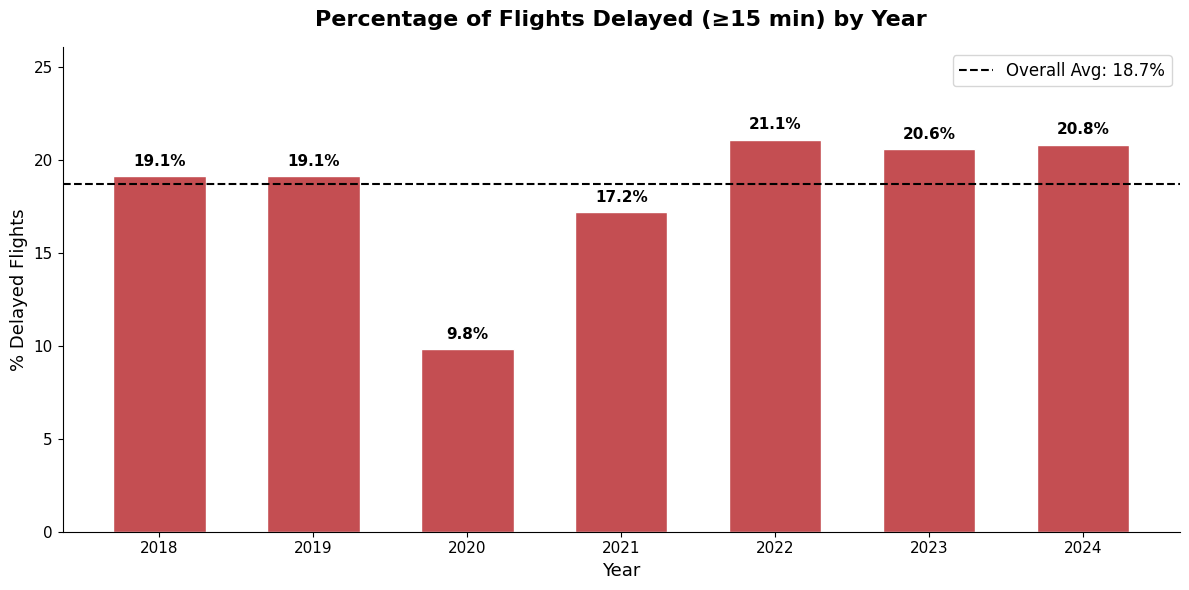

In [18]:
# ── Calculate % Delayed by Year ──────────────────────────────────────
delay_pct = (
    df.groupby("Year")["ArrDel15"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={"ArrDel15": "Pct_Delayed"})
)

print(delay_pct)

# ══════════════════════════════════════════════════════════════════════
# Bar Chart
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    delay_pct["Year"].astype(str),
    delay_pct["Pct_Delayed"],
    color="#c44e52",
    edgecolor="white",
    width=0.6
)

# ── Add value labels on top of each bar ──────────────────────────────
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.4,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ── Add a horizontal reference line at the overall average ───────────
overall_avg = df["ArrDel15"].mean() * 100
ax.axhline(
    y=overall_avg,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Avg: {overall_avg:.1f}%"
)

# ── Formatting ───────────────────────────────────────────────────────
ax.set_title("Percentage of Flights Delayed (≥15 min) by Year",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("% Delayed Flights", fontsize=13)
ax.set_ylim(0, delay_pct["Pct_Delayed"].max() + 5)
ax.legend(fontsize=12, loc="upper right")
ax.tick_params(axis="both", labelsize=11)

# Remove top & right spines for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("delay_pct_by_year.png", dpi=150, bbox_inches="tight")
plt.show()


# Temporal EDA

## Section 1 — Setup & Shared Utilities

In [19]:
# Use the already-loaded dataset
bts_merged = df.copy()
print(f'Working dataset: {bts_merged.shape}')
print(f'Memory usage: {bts_merged.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Working dataset: (45968068, 54)
Memory usage: 27.18 GB


In [20]:
# Aesthetics
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
sns.set_palette('tab10')

# Label maps
MONTH_NAMES = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
DOW_NAMES = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
QTR_NAMES = {1:'Q1\n(Jan-Mar)', 2:'Q2\n(Apr-Jun)',
             3:'Q3\n(Jul-Sep)', 4:'Q4\n(Oct-Dec)'}

YEARS   = sorted(bts_merged['Year'].unique())
PALETTE = dict(zip(YEARS, sns.color_palette('tab10', len(YEARS))))

# Format y-axis as percentage
def pct_fmt(ax, decimals=0):
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y*100:.{decimals}f}%'))

# Annotate bars with their value
def annotate_bars(ax, fmt='{:.1%}', color='black', fontsize=8):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h) and h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom',
                        fontsize=fontsize, color=color)

print('✅ Setup complete — YEARS:', YEARS)

✅ Setup complete — YEARS: [2018, 2019, 2020, 2021, 2022, 2023, 2024]


---
## Section 2 — Data Prep

In [21]:
# Work on rows where ArrDel15 is not null
df = bts_merged.dropna(subset=['ArrDel15']).copy()
df['ArrDel15'] = df['ArrDel15'].astype(float)

# Convenience date column
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# More-readable labels
df['MonthName'] = df['Month'].map(MONTH_NAMES)
df['DayName']   = df['DayOfWeek'].map(DOW_NAMES)

# ISO week for rolling series
df['YearWeek'] = df['FlightDate'].dt.to_period('W')

print(f'Working rows : {len(df):,}')
print(f'Delay rate   : {df["ArrDel15"].mean():.2%}')
print(f'Date range   : {df["FlightDate"].min().date()} → {df["FlightDate"].max().date()}')

Working rows : 44,858,152
Delay rate   : 18.72%
Date range   : 2018-01-01 → 2024-12-31


---
## Section 3 — Macro Overview: Flight Volume & Delay Rate by Year

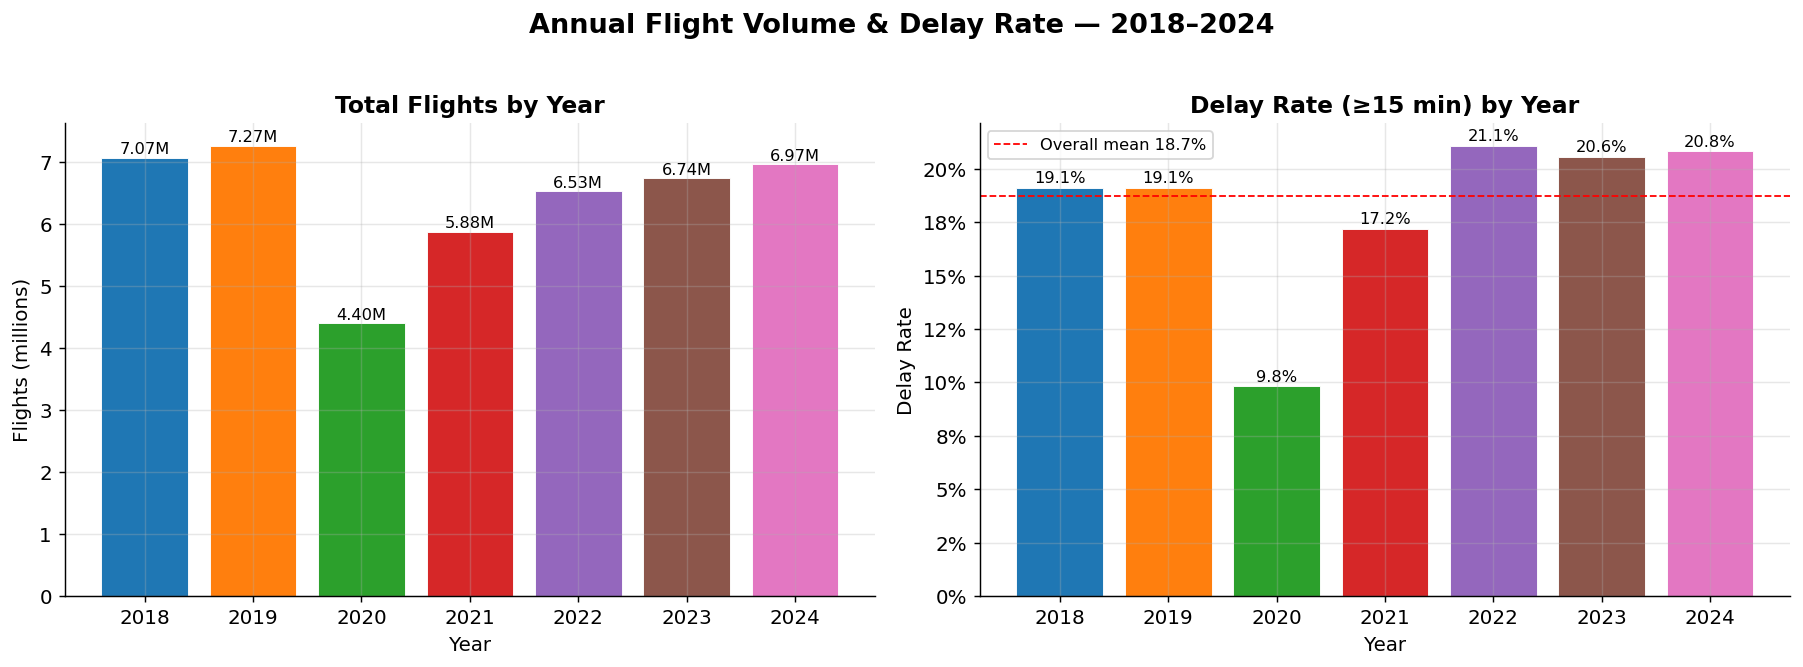

In [22]:
yearly = (
    df.groupby('Year')
      .agg(flights=('ArrDel15','count'), delay_rate=('ArrDel15','mean'))
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flight Volume
ax = axes[0]
bars = ax.bar(yearly['Year'].astype(str), yearly['flights'] / 1e6,
              color=[PALETTE[y] for y in yearly['Year']], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, yearly['flights']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
ax.set_title('Total Flights by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Flights (millions)')
ax.set_xlabel('Year')

# Delay Rate
ax = axes[1]
bars = ax.bar(yearly['Year'].astype(str), yearly['delay_rate'],
              color=[PALETTE[y] for y in yearly['Year']], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, yearly['delay_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.1%}', ha='center', va='bottom', fontsize=9)
pct_fmt(ax, decimals=0)
ax.set_title('Delay Rate (≥15 min) by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Delay Rate')
ax.set_xlabel('Year')
ax.axhline(df['ArrDel15'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'Overall mean {df["ArrDel15"].mean():.1%}')
ax.legend(fontsize=9)

fig.suptitle('Annual Flight Volume & Delay Rate — 2018–2024',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_annual_overview.png', bbox_inches='tight')
plt.show()

In [23]:
print('   Note: 2020 volume collapse (−39%) reflects COVID-19 shutdown.')
print('   Post-2020 delay rates are uniformly higher (~21%) than pre-COVID (~19%).')

   Note: 2020 volume collapse (−39%) reflects COVID-19 shutdown.
   Post-2020 delay rates are uniformly higher (~21%) than pre-COVID (~19%).


---
## Section 4 — Monthly Seasonality by Year (Jan–Dec)

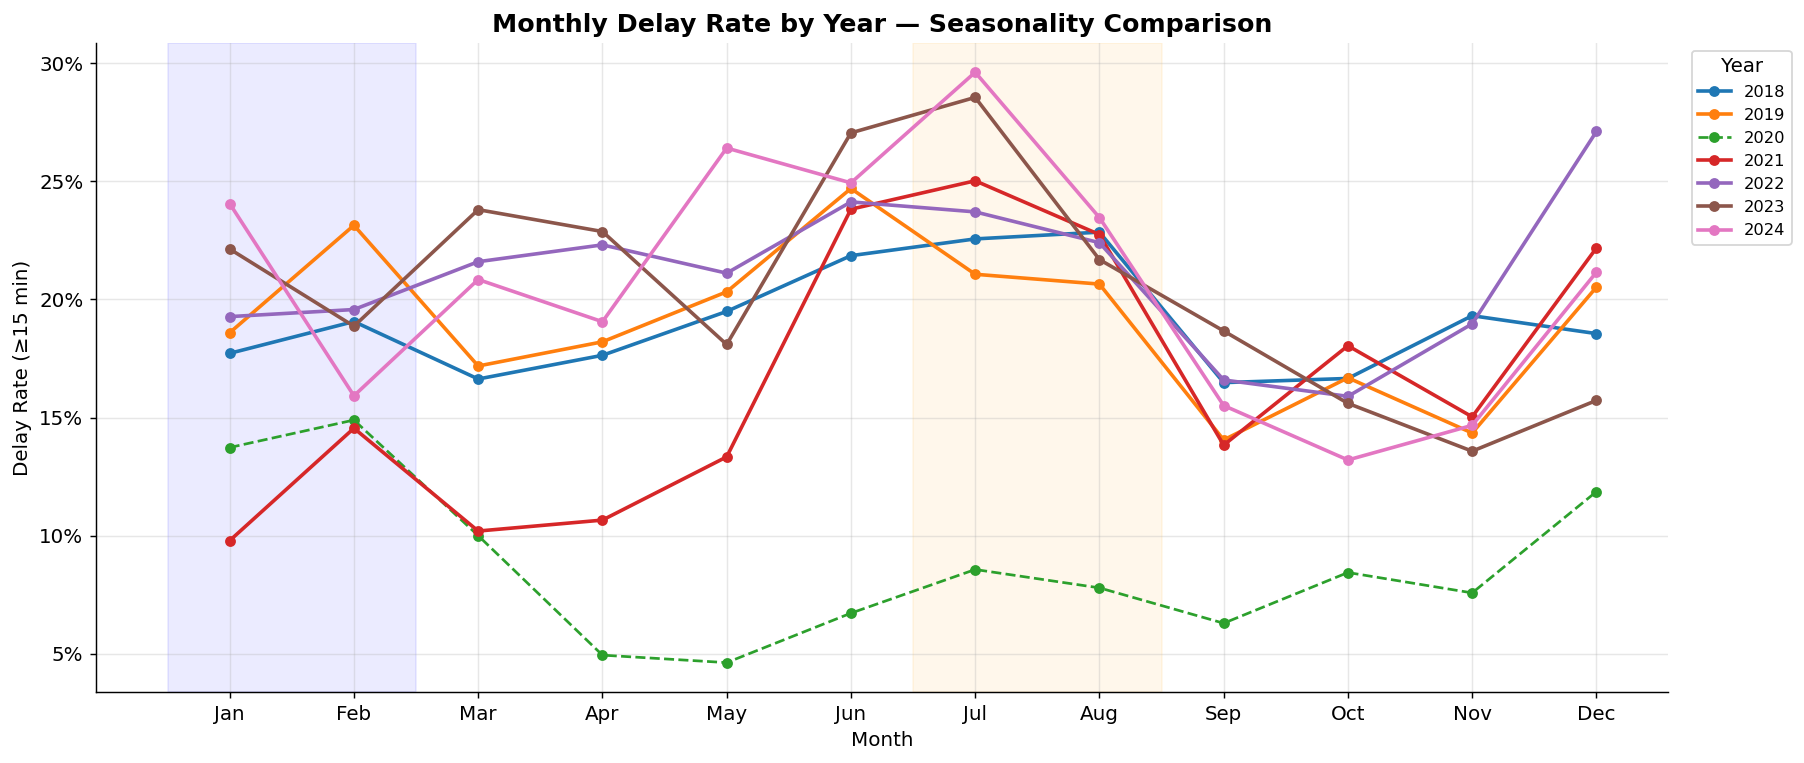

In [24]:
# 4a. Line chart: delay rate by month, one line per year
monthly = (
    df.groupby(['Year','Month'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for year in YEARS:
    sub = monthly[monthly['Year'] == year].sort_values('Month')
    # dashed for COVID year
    ls  = '--' if year == 2020 else '-'
    lw  = 1.5  if year == 2020 else 2.0
    ax.plot(sub['Month'], sub['delay_rate'],
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=lw, marker='o', markersize=5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)])
pct_fmt(ax, decimals=0)
ax.set_title('Monthly Delay Rate by Year — Seasonality Comparison',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Shade summer and winter peaks
ax.axvspan(6.5, 8.5, alpha=0.08, color='orange', label='Summer Peak')
ax.axvspan(0.5, 2.5, alpha=0.08, color='blue',   label='Winter Peak')

plt.tight_layout()
plt.savefig('fig_02_monthly_delay_by_year.png', bbox_inches='tight')
plt.show()

In [25]:
print('   Two seasonal peaks are consistently present:')
print('   - Winter (Dec–Jan): Likely due to weather-driven delays (ice, snow, low visibility)')
print('   - Summer (Jun–Aug): Likely due to convective storms + demand congestion')
print('   2020 collapses entirely — especially Apr–Jun during lockdown.')

   Two seasonal peaks are consistently present:
   - Winter (Dec–Jan): Likely due to weather-driven delays (ice, snow, low visibility)
   - Summer (Jun–Aug): Likely due to convective storms + demand congestion
   2020 collapses entirely — especially Apr–Jun during lockdown.


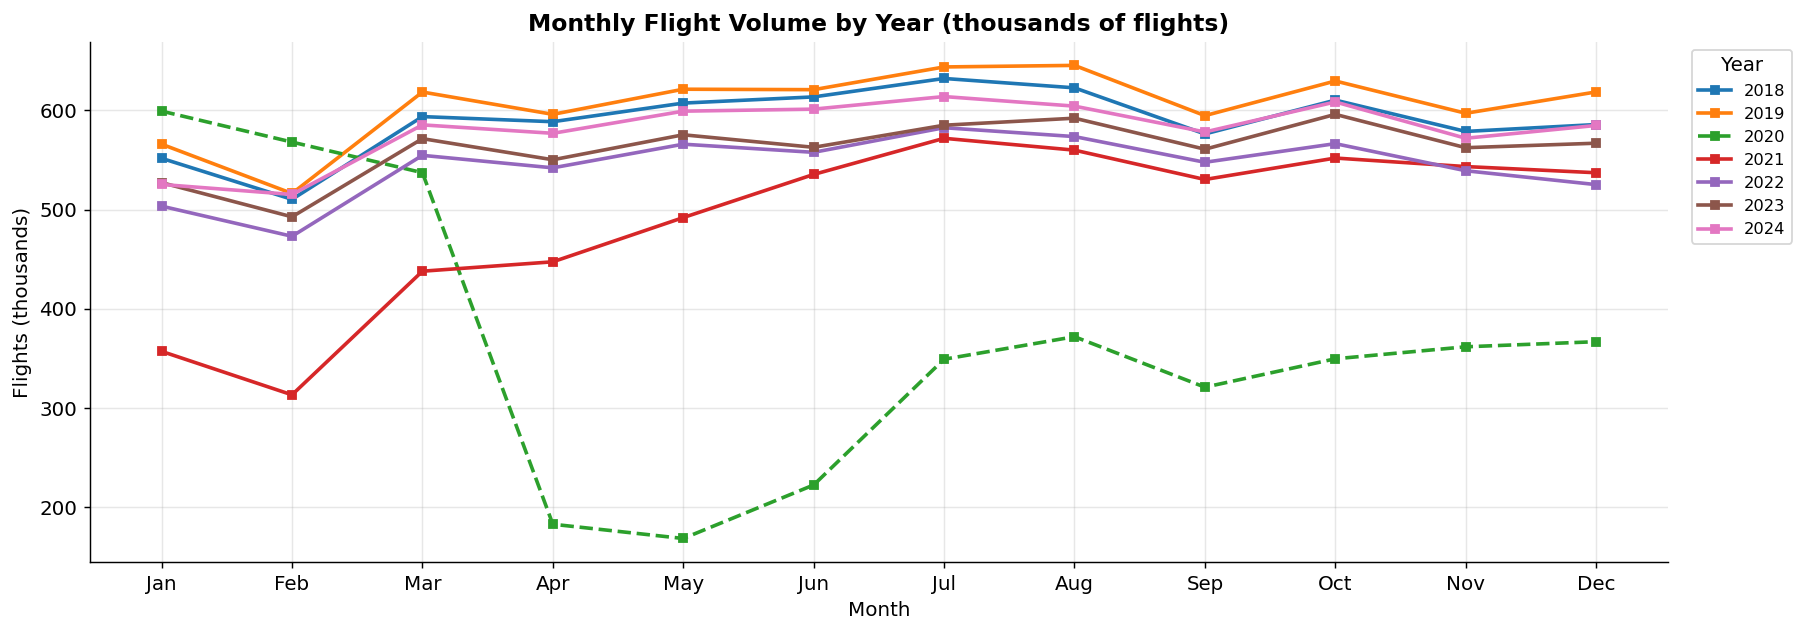

In [26]:
# 4b. Monthly flight VOLUME by year (area chart)
fig, ax = plt.subplots(figsize=(14, 5))

for year in YEARS:
    sub = monthly[monthly['Year'] == year].sort_values('Month')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['Month'], sub['flights'] / 1000,
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='s', markersize=4)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)])
ax.set_title('Monthly Flight Volume by Year (thousands of flights)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Flights (thousands)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_03_monthly_volume_by_year.png', bbox_inches='tight')
plt.show()

In [27]:
print('   Small but consistent increased volume reflects summer travel demand surge (Jun–Aug) in every year.')
print('   Feb dip = shortest month.  2020 Apr–Jun plunge = COVID grounding.')

   Small but consistent increased volume reflects summer travel demand surge (Jun–Aug) in every year.
   Feb dip = shortest month.  2020 Apr–Jun plunge = COVID grounding.


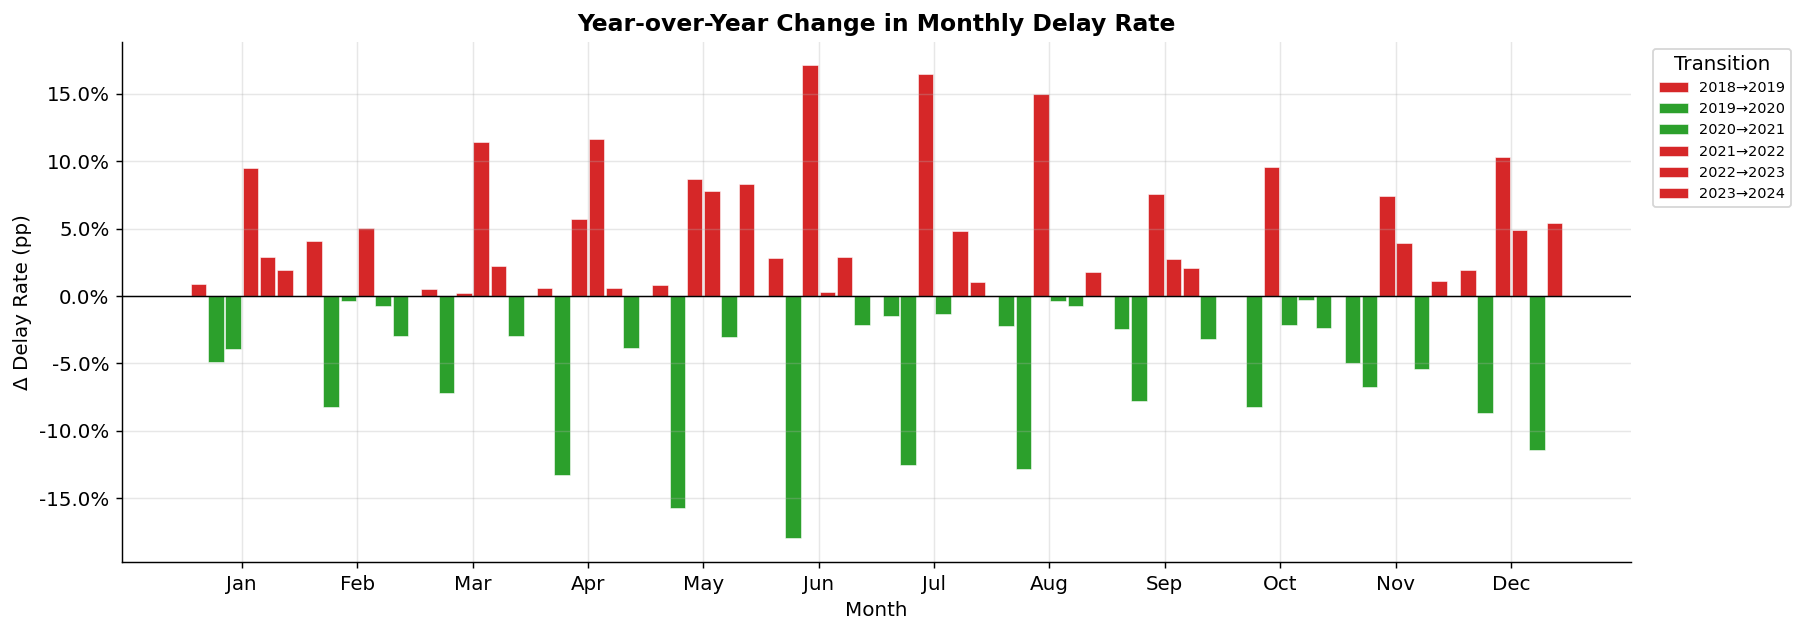

In [28]:
# 4c. Year-over-Year monthly delay rate DELTA (vs prior year)
monthly_pivot = monthly.pivot(index='Month', columns='Year', values='delay_rate')
yoy_delta     = monthly_pivot.diff(axis=1).drop(columns=YEARS[0])  # drop 2018 (no prior)

fig, ax = plt.subplots(figsize=(14, 5))
cmap_diverge = plt.cm.RdYlGn_r  # red = delay increase, green = decrease

x      = np.arange(12)
n_yrs  = len(YEARS) - 1
width  = 0.9 / n_yrs

for i, year in enumerate(YEARS[1:]):
    vals   = yoy_delta[year].values
    offset = (i - n_yrs / 2 + 0.5) * width
    colors = ['#d62728' if v > 0 else '#2ca02c' for v in vals]
    ax.bar(x + offset, vals, width=width * 0.9,
           color=colors, edgecolor='white', linewidth=0.3,
           label=f'{year - 1}→{year}')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)])
pct_fmt(ax, decimals=1)
ax.set_title('Year-over-Year Change in Monthly Delay Rate',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Δ Delay Rate (pp)')
ax.legend(title='Transition', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('fig_04_monthly_yoy_delta.png', bbox_inches='tight')
plt.show()

In [29]:
print('   Red = delay rate worsened vs prior year.  Green = improved.')
print('   2019→2020 shows dramatic green (COVID reduced demand AND delays).')
print('   2020→2021 also remains green as industry pushes initial recovery but returns to red post 2021.')

   Red = delay rate worsened vs prior year.  Green = improved.
   2019→2020 shows dramatic green (COVID reduced demand AND delays).
   2020→2021 also remains green as industry pushes initial recovery but returns to red post 2021.


---
## Section 5 — Day-of-Week Seasonality by Year (Mon–Sun)

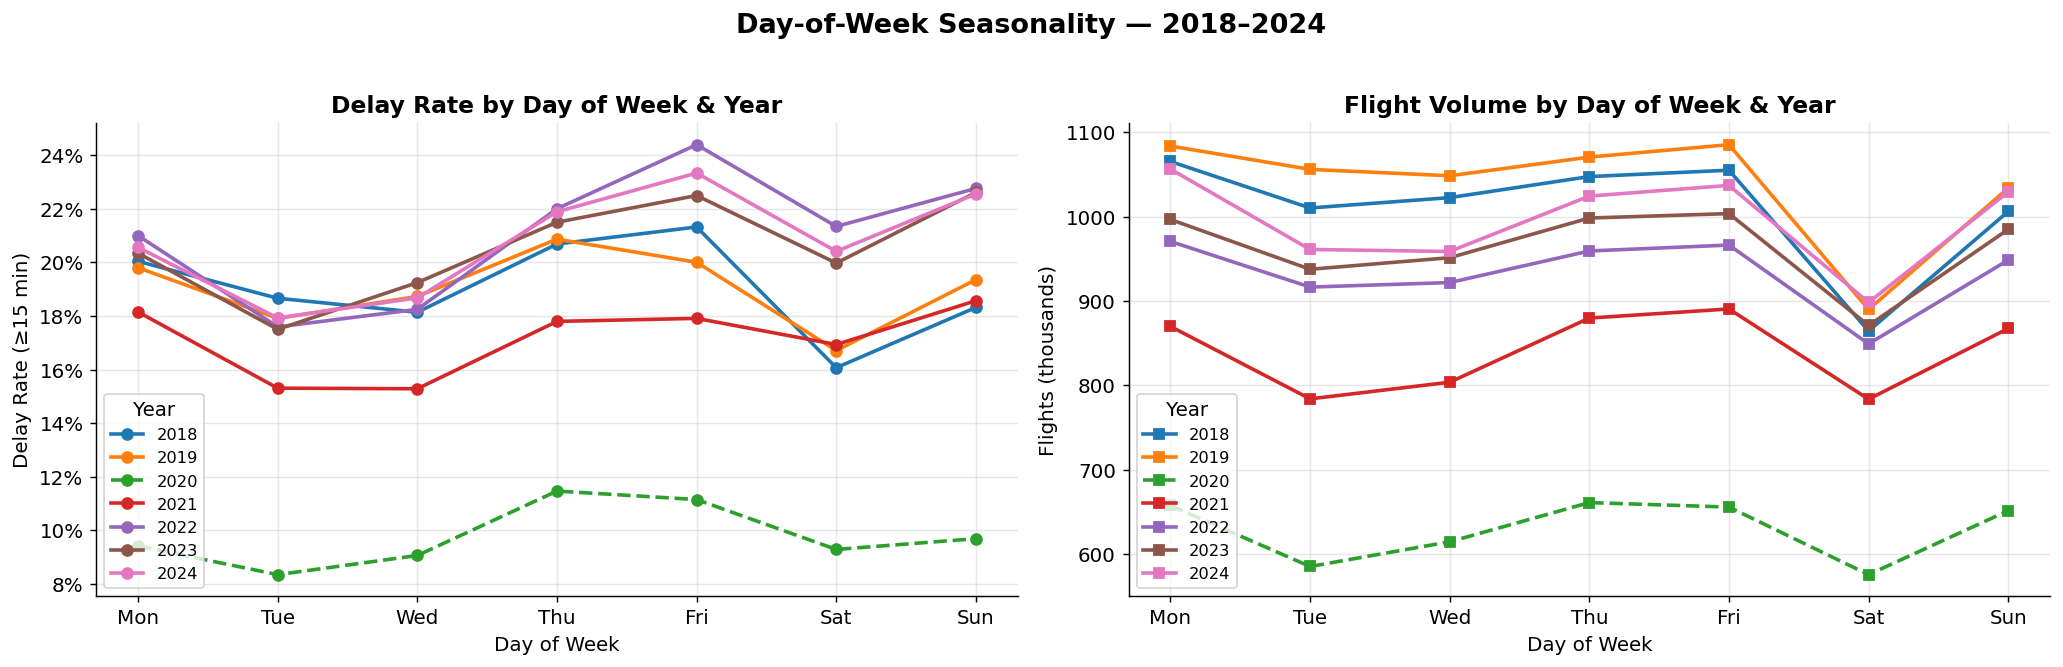

In [30]:
# 5a. Line chart: delay rate by day of week, one line per year
dow = (
    df.groupby(['Year','DayOfWeek'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Delay rate
ax = axes[0]
for year in YEARS:
    sub = dow[dow['Year'] == year].sort_values('DayOfWeek')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['DayOfWeek'], sub['delay_rate'],
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='o', markersize=6)

ax.set_xticks(range(1, 8))
ax.set_xticklabels([DOW_NAMES[d] for d in range(1, 8)])
pct_fmt(ax)
ax.set_title('Delay Rate by Day of Week & Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', fontsize=9)

# Flight volume
ax = axes[1]
for year in YEARS:
    sub = dow[dow['Year'] == year].sort_values('DayOfWeek')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['DayOfWeek'], sub['flights'] / 1000,
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='s', markersize=5)

ax.set_xticks(range(1, 8))
ax.set_xticklabels([DOW_NAMES[d] for d in range(1, 8)])
ax.set_title('Flight Volume by Day of Week & Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Flights (thousands)')
ax.legend(title='Year', fontsize=9)

fig.suptitle('Day-of-Week Seasonality — 2018–2024',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_05_dow_seasonality.png', bbox_inches='tight')
plt.show()

In [31]:
print('   Friday typically shows the highest delay rate (Likely due to network congestion).')
print('   Tuesdays and Wednesdays typically shows the lowest delay rate.')
print('   This day-of-week pattern is structurally stable across most years, including 2020.')

   Friday typically shows the highest delay rate (Likely due to network congestion).
   Tuesdays and Wednesdays typically shows the lowest delay rate.
   This day-of-week pattern is structurally stable across most years, including 2020.


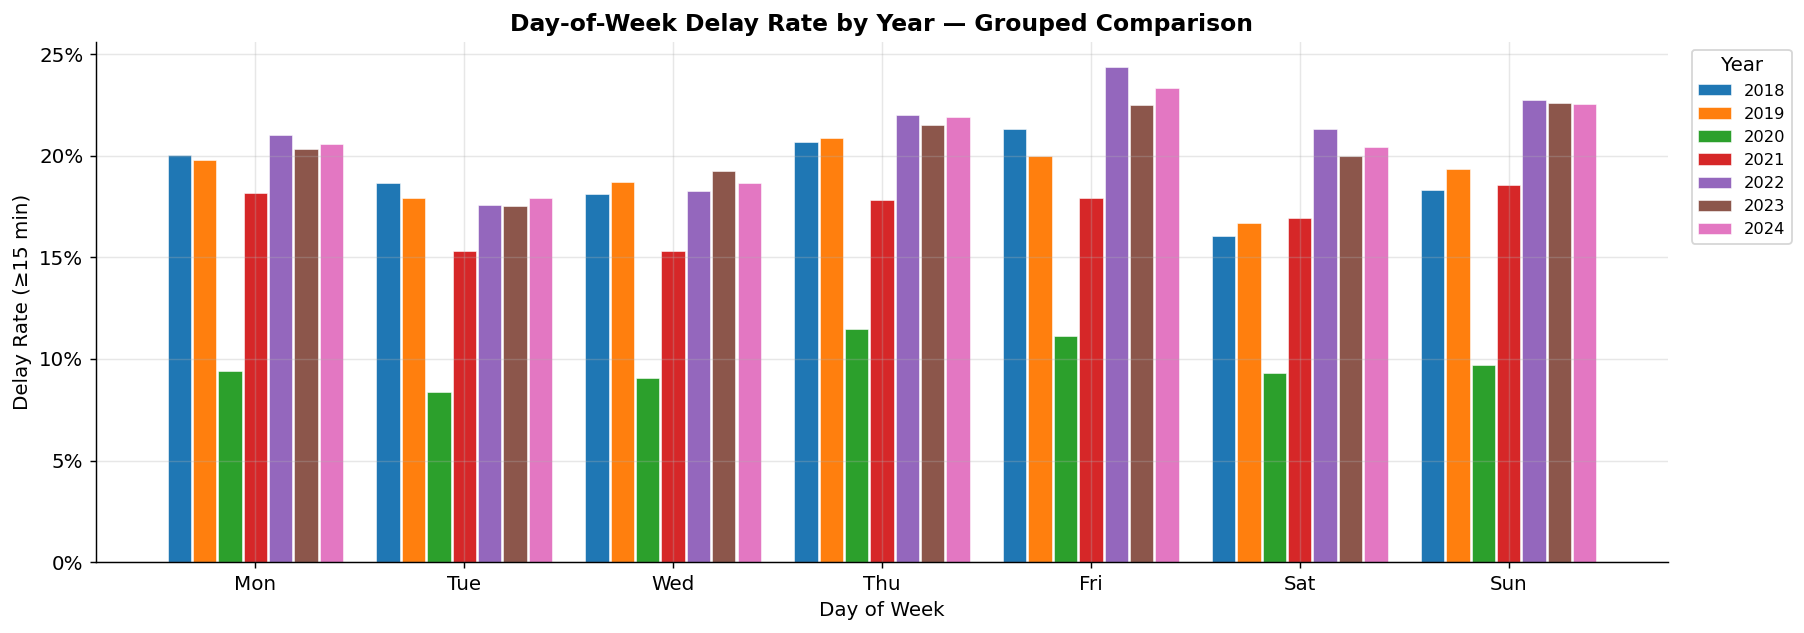

In [32]:
# 5b. Grouped bar chart — delay rate by DoW for each year
dow_pivot = dow.pivot(index='DayOfWeek', columns='Year', values='delay_rate')

fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(7)
n     = len(YEARS)
w     = 0.85 / n

for i, year in enumerate(YEARS):
    vals   = dow_pivot[year].values
    offset = (i - n/2 + 0.5) * w
    ax.bar(x + offset, vals, width=w * 0.92,
           color=PALETTE[year], label=str(year), edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([DOW_NAMES[d] for d in range(1, 8)])
pct_fmt(ax)
ax.set_title('Day-of-Week Delay Rate by Year — Grouped Comparison',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_06_dow_grouped_bar.png', bbox_inches='tight')
plt.show()

---
## Section 6 — Hourly / Intraday Seasonality by Year

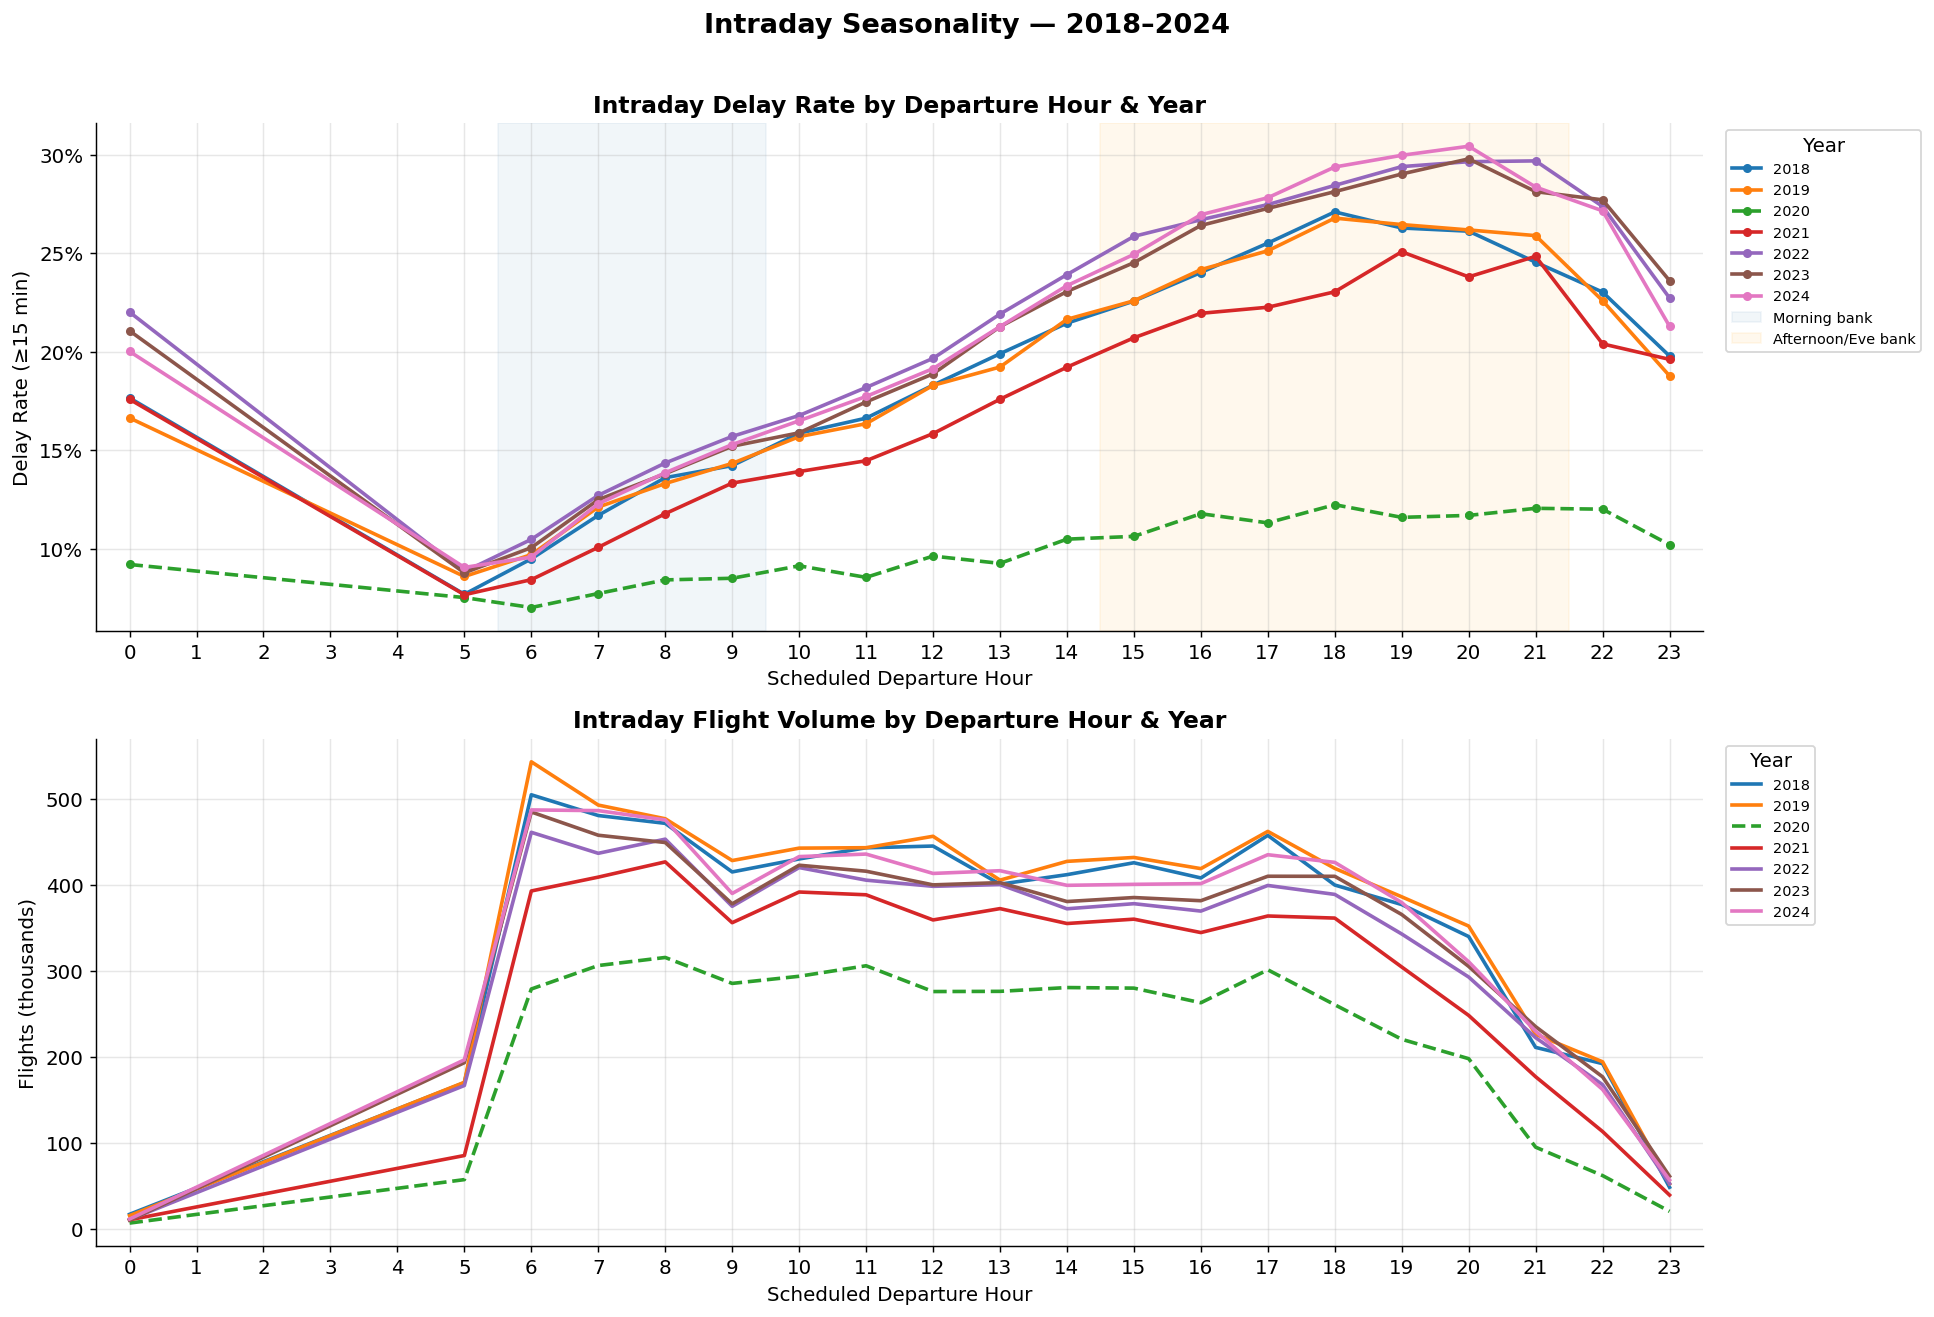

In [33]:
# 6a. Delay rate by departure hour, per year
hourly = (
    df.groupby(['Year','dep_hour'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)
# Only hours with meaningful volume (filter out midnight wrap-arounds with < 0.1% of flights)
total_by_yr = hourly.groupby('Year')['flights'].transform('sum')
hourly      = hourly[hourly['flights'] / total_by_yr > 0.001].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Delay rate by hour
ax = axes[0]
for year in YEARS:
    sub = hourly[hourly['Year'] == year].sort_values('dep_hour')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['dep_hour'], sub['delay_rate'],
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='o', markersize=4)

# Shade morning and evening banks
ax.axvspan(5.5, 9.5,  alpha=0.07, color='steelblue', label='Morning bank')
ax.axvspan(14.5, 21.5, alpha=0.07, color='orange',   label='Afternoon/Eve bank')
pct_fmt(ax)
ax.set_xticks(range(0, 24))
ax.set_title('Intraday Delay Rate by Departure Hour & Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlim(-0.5, 23.5)

# Volume by hour
ax = axes[1]
for year in YEARS:
    sub = hourly[hourly['Year'] == year].sort_values('dep_hour')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['dep_hour'], sub['flights'] / 1000,
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2)

ax.set_xticks(range(0, 24))
ax.set_title('Intraday Flight Volume by Departure Hour & Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('Flights (thousands)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlim(-0.5, 23.5)

fig.suptitle('Intraday Seasonality — 2018–2024',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_07_intraday_seasonality.png', bbox_inches='tight')
plt.show()

In [34]:
print('   Early morning departures (05:00–08:00) have a massive increase in volume')
print('   Delays increase almost linearly from 05:00 throughout the day, peaking at 18:00–20:00 (Likely network congestion propagation).')
print('   IMPORTANT for the T-2h window: the departure hour itself seems to be a strong predictor.')

   Early morning departures (05:00–08:00) have a massive increase in volume
   Delays increase almost linearly from 05:00 throughout the day, peaking at 18:00–20:00 (Likely network congestion propagation).
   IMPORTANT for the T-2h window: the departure hour itself seems to be a strong predictor.


---
## Section 7 — Quarterly Seasonality by Year

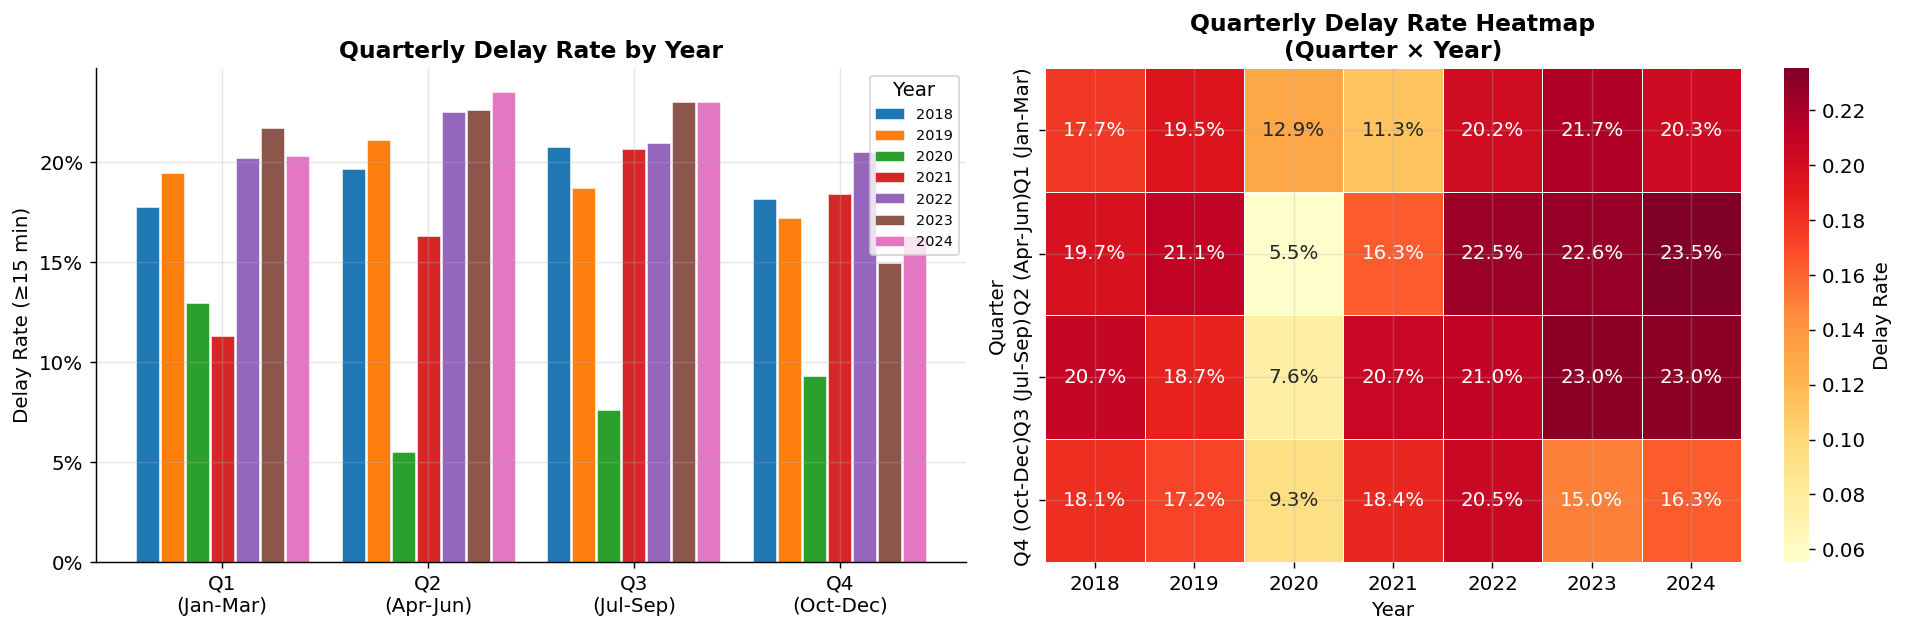

In [35]:
quarterly = (
    df.groupby(['Year','Quarter'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar: delay rate
ax = axes[0]
x = np.arange(4)
n = len(YEARS)
w = 0.85 / n
for i, year in enumerate(YEARS):
    sub    = quarterly[quarterly['Year'] == year].sort_values('Quarter')
    offset = (i - n/2 + 0.5) * w
    ax.bar(x + offset, sub['delay_rate'], width=w * 0.92,
           color=PALETTE[year], label=str(year), edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([QTR_NAMES[q] for q in range(1, 5)])
pct_fmt(ax)
ax.set_title('Quarterly Delay Rate by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', fontsize=8)

# Heatmap: quarter × year
ax = axes[1]
qtr_pivot = quarterly.pivot(index='Quarter', columns='Year', values='delay_rate')
qtr_pivot.index = [QTR_NAMES[q].replace('\n',' ') for q in qtr_pivot.index]
sns.heatmap(qtr_pivot, annot=True, fmt='.1%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Delay Rate'})
ax.set_title('Quarterly Delay Rate Heatmap\n(Quarter × Year)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Quarter')

plt.tight_layout()
plt.savefig('fig_08_quarterly_seasonality.png', bbox_inches='tight')
plt.show()

In [36]:
print('   Q2-3 (Covering early and late summer respectively) are typically the highest-delay quarters, with 2020 being an expected exception.')
print('   Q4 is typically the lowest outside of COVID.')
print('   2020 Q1 already shows COVID impact (March shutdown); Q2 is anomalously low.')

   Q2-3 (Covering early and late summer respectively) are typically the highest-delay quarters, with 2020 being an expected exception.
   Q4 is typically the lowest outside of COVID.
   2020 Q1 already shows COVID impact (March shutdown); Q2 is anomalously low.


---
## Section 8 — Heatmap Grid: Month × Year and DoW × Year

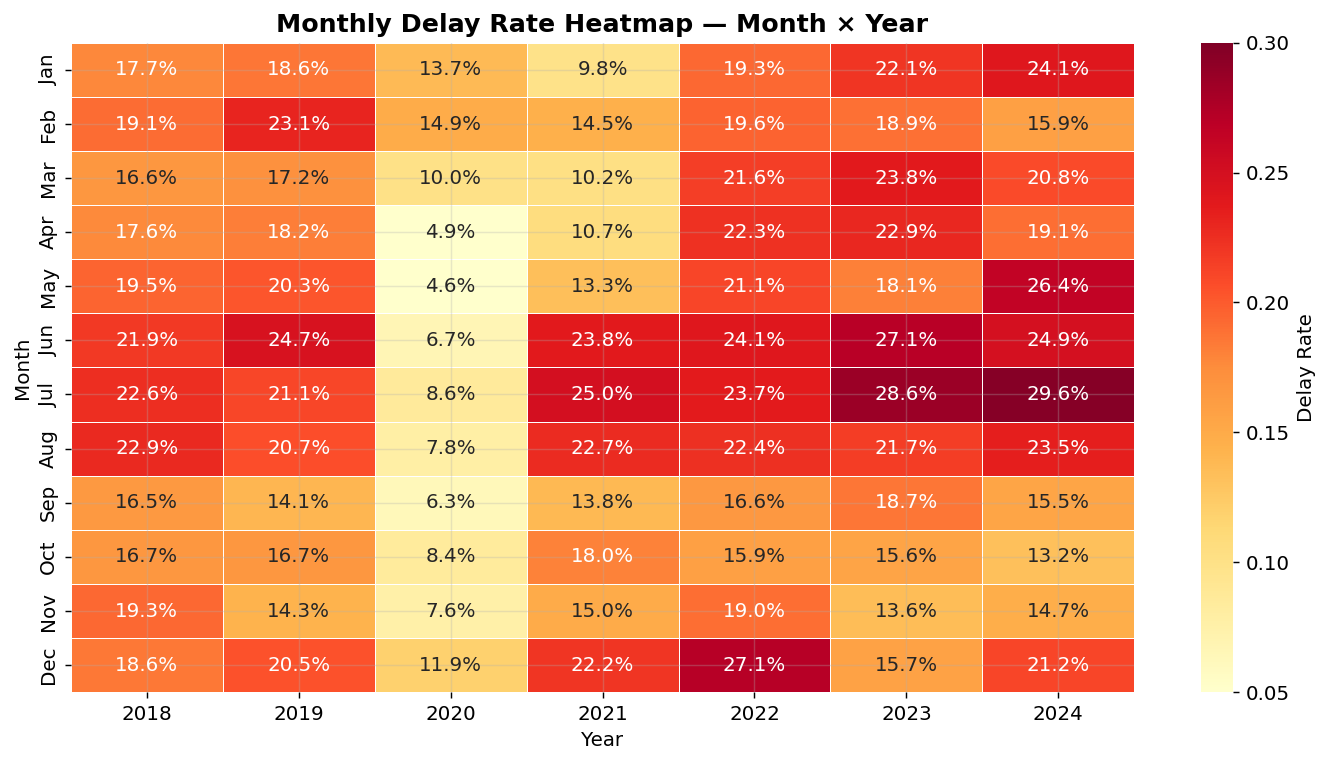

In [37]:
# 8a. Delay Rate Heatmap — Month × Year
month_pivot = (
    df.groupby(['Year','Month'])['ArrDel15']
      .mean()
      .unstack('Year')
)
month_pivot.index = [MONTH_NAMES[m] for m in month_pivot.index]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    month_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'YlOrRd',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.05,
    vmax     = 0.30,
)
ax.set_title('Monthly Delay Rate Heatmap — Month × Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Month')

plt.tight_layout()
plt.savefig('fig_09a_heatmap_month_year.png', bbox_inches='tight')
plt.show()

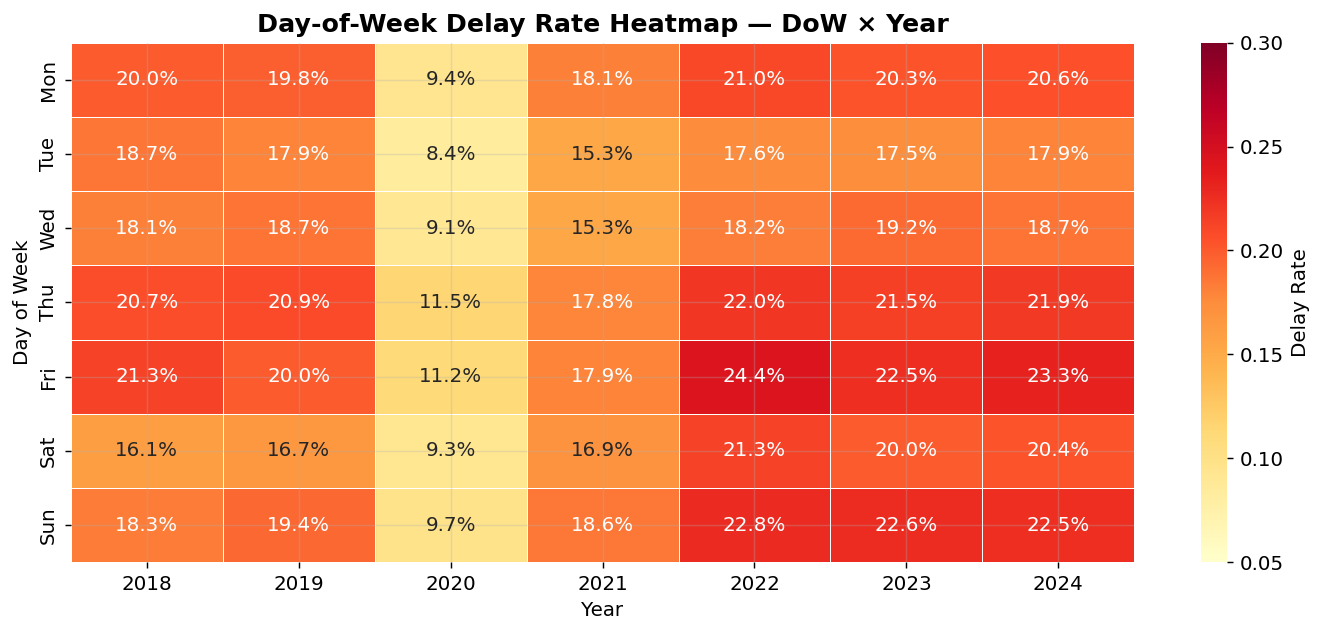

In [38]:
# 8b. Delay Rate Heatmap — Day-of-Week × Year
dow_pivot = (
    df.groupby(['Year','DayOfWeek'])['ArrDel15']
      .mean()
      .unstack('Year')
)
dow_pivot.index = [DOW_NAMES[d] for d in dow_pivot.index]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    dow_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'YlOrRd',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.05,
    vmax     = 0.30,
)
ax.set_title('Day-of-Week Delay Rate Heatmap — DoW × Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('fig_09b_heatmap_dow_year.png', bbox_inches='tight')
plt.show()

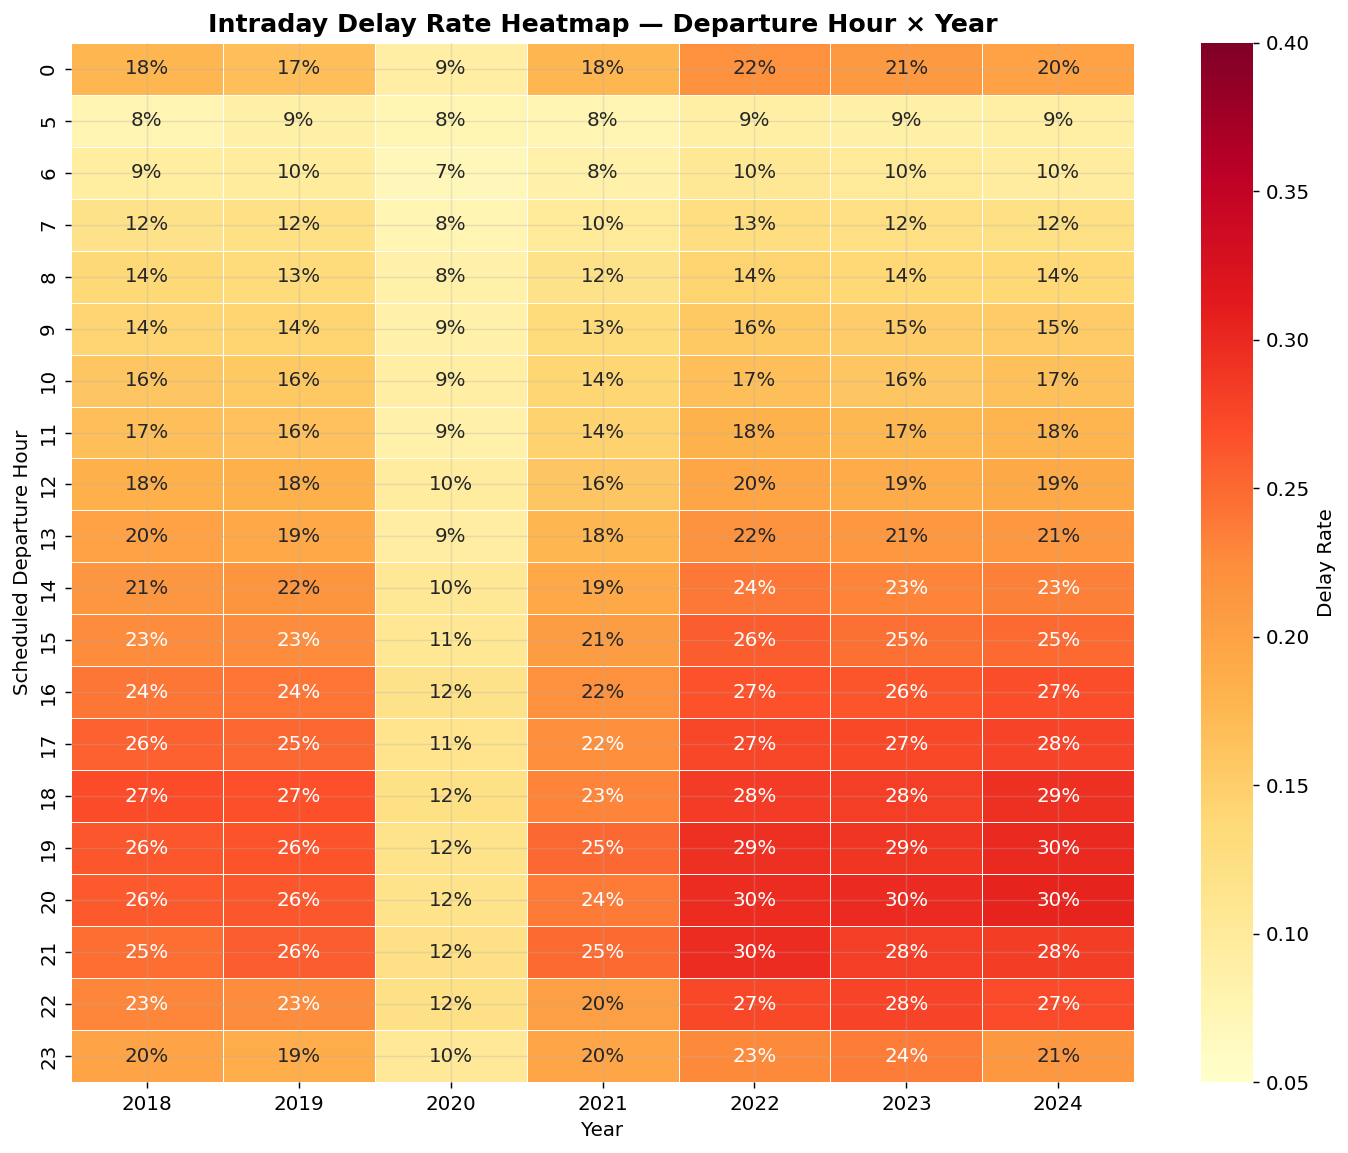

In [39]:
# 8c. Delay Rate Heatmap — Departure Hour × Year
hr_pivot = (
    df.groupby(['Year','dep_hour'])['ArrDel15']
      .agg(delay_rate='mean', cnt='count')
      .reset_index()
)
# Filter low-volume hour-year combos
yr_totals = hr_pivot.groupby('Year')['cnt'].transform('sum')
hr_pivot  = hr_pivot[hr_pivot['cnt'] / yr_totals > 0.001]
hr_pivot2 = hr_pivot.pivot(index='dep_hour', columns='Year', values='delay_rate')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    hr_pivot2,
    annot    = True,
    fmt      = '.0%',
    cmap     = 'YlOrRd',
    linewidths = 0.3,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.05,
    vmax     = 0.40,
)
ax.set_title('Intraday Delay Rate Heatmap — Departure Hour × Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Scheduled Departure Hour')

plt.tight_layout()
plt.savefig('fig_09c_heatmap_hour_year.png', bbox_inches='tight')
plt.show()


In [40]:
print('   The hour × year heatmap appears to be of strong importance for our models:')
print('   High delay hours (18–21) are consistent across ALL years, even 2020.')

   The hour × year heatmap appears to be of strong importance for our models:
   High delay hours (18–21) are consistent across ALL years, even 2020.


---
## Section 9 — COVID Structural Break: Annotated Monthly Time Series

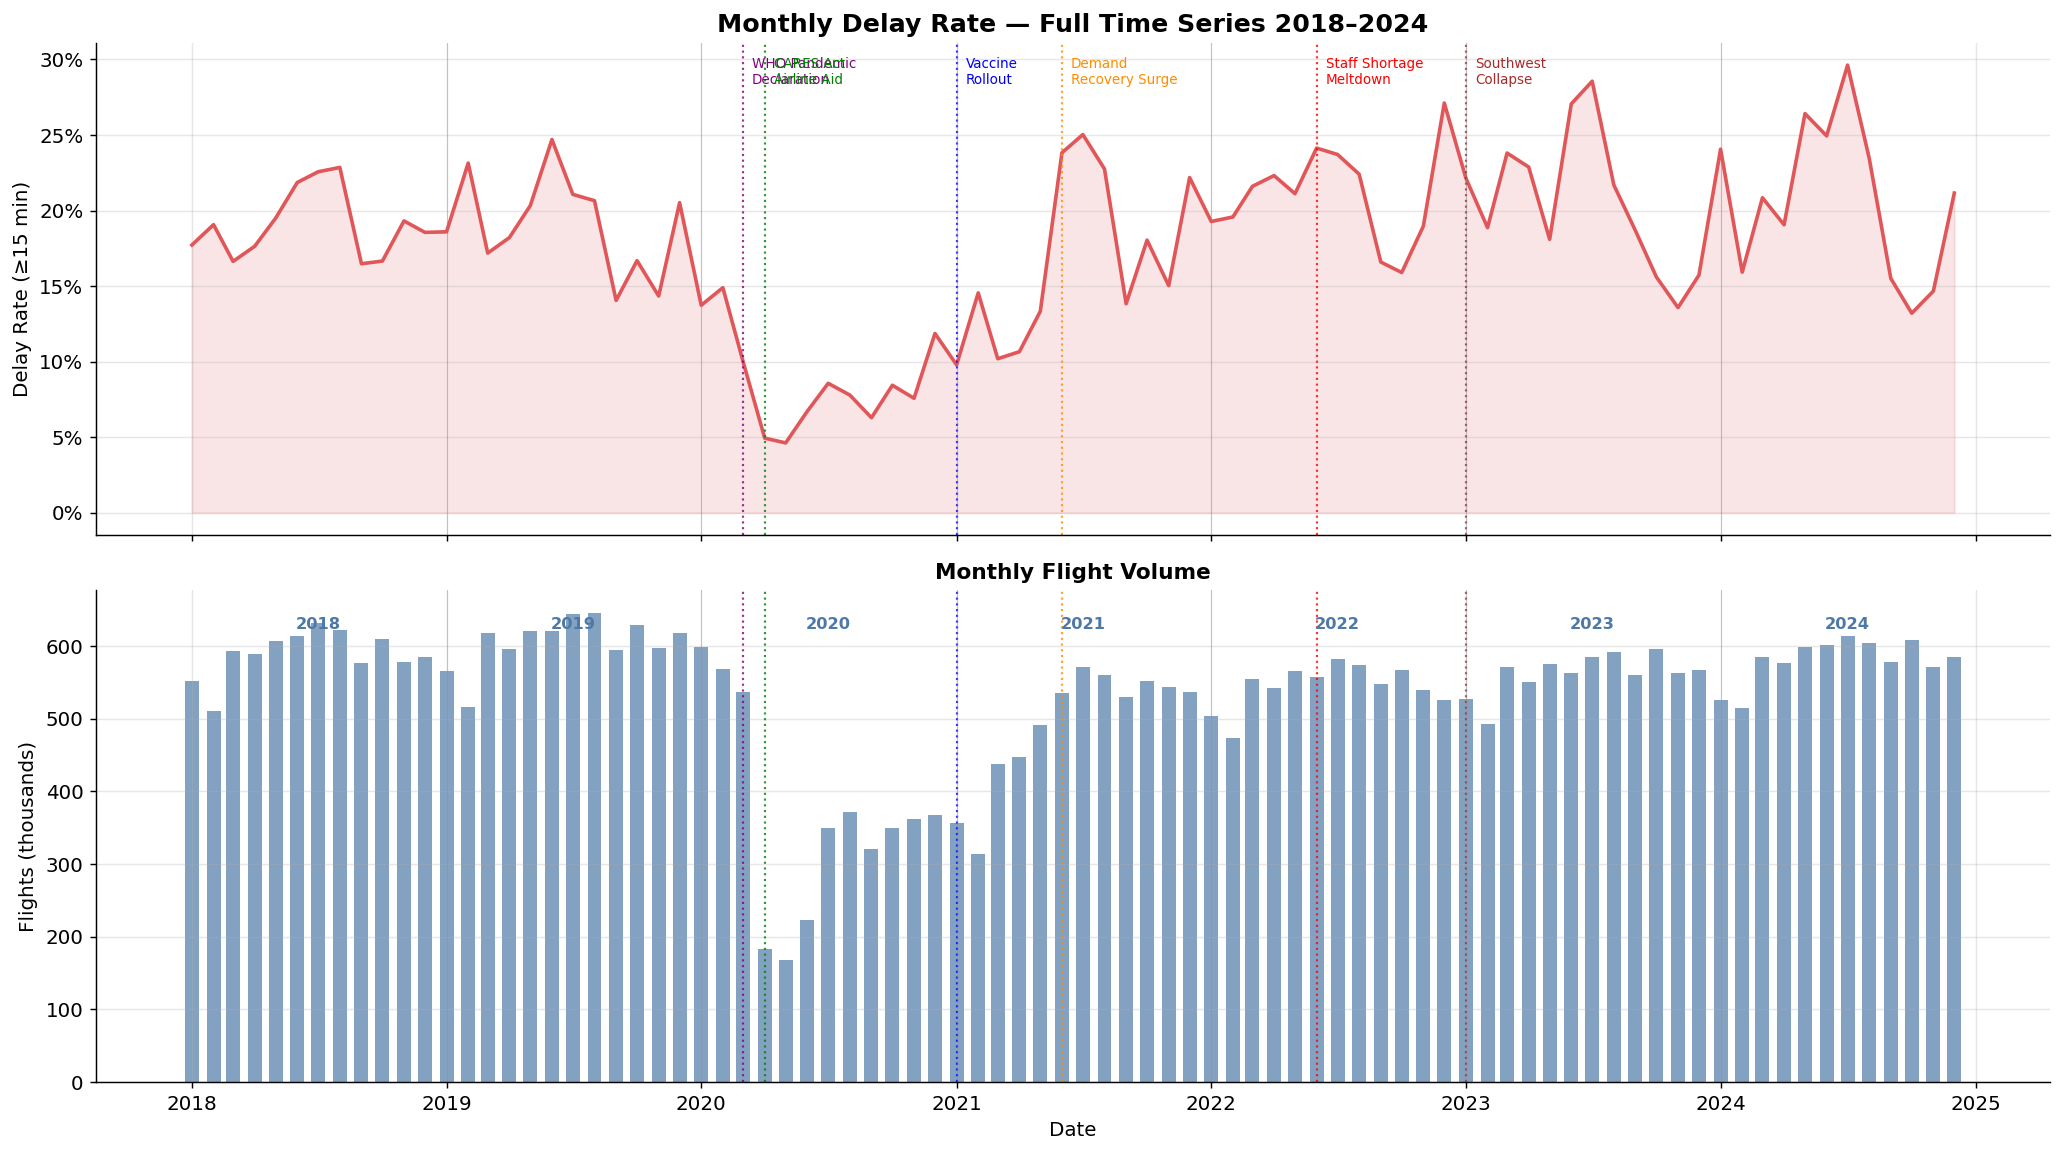

In [41]:
# Full monthly time series 2018–2024
monthly_ts = (
    df.groupby(['Year','Month'])
      .agg(delay_rate=('ArrDel15','mean'), flights=('ArrDel15','count'))
      .reset_index()
)
monthly_ts['period'] = pd.to_datetime(
    monthly_ts['Year'].astype(str) + '-' +
    monthly_ts['Month'].astype(str).str.zfill(2) + '-01'
)
monthly_ts = monthly_ts.sort_values('period')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# — Panel 1: Delay rate —
ax1.plot(monthly_ts['period'], monthly_ts['delay_rate'],
         color='#e15759', linewidth=2, label='Monthly delay rate')
ax1.fill_between(monthly_ts['period'], monthly_ts['delay_rate'],
                 alpha=0.15, color='#e15759')
pct_fmt(ax1)
ax1.set_ylabel('Delay Rate (≥15 min)', fontsize=11)
ax1.set_title('Monthly Delay Rate — Full Time Series 2018–2024',
              fontsize=14, fontweight='bold')

# Panel 2: Flight volume
ax2.bar(monthly_ts['period'], monthly_ts['flights'] / 1000,
        width=20, color='#4e79a7', alpha=0.7, label='Flights (thousands)')
ax2.set_ylabel('Flights (thousands)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_title('Monthly Flight Volume', fontsize=12, fontweight='bold')

# Annotations
events = [
    ('2020-03-01', 'WHO Pandemic\nDeclaration', 'purple'),
    ('2020-04-01', 'CARES Act\nAirline Aid',    'green'),
    ('2021-01-01', 'Vaccine\nRollout',           'blue'),
    ('2021-06-01', 'Demand\nRecovery Surge',     'darkorange'),
    ('2022-06-01', 'Staff Shortage\nMeltdown',   'red'),
    ('2023-01-01', 'Southwest\nCollapse',        'brown'),
]

for date_str, label, color in events:
    dt = pd.Timestamp(date_str)
    for ax in [ax1, ax2]:
        ax.axvline(dt, color=color, linestyle=':', linewidth=1.2, alpha=0.8)
    ax1.annotate(
        label, xy=(dt, ax1.get_ylim()[1] * 0.97),
        xytext=(5, 0), textcoords='offset points',
        fontsize=7.5, color=color, va='top',
        rotation=0,
    )

# Year boundaries
for yr in range(2019, 2025):
    for ax in [ax1, ax2]:
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
                   linestyle='-', linewidth=0.5, alpha=0.4)

# Year labels
for yr in YEARS:
    ax2.text(pd.Timestamp(f'{yr}-07-01'), ax2.get_ylim()[1] * 0.92,
             str(yr), ha='center', fontsize=9, color='#4e79a7', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_10_covid_annotated_ts.png', bbox_inches='tight')
plt.show()

In [42]:
print('   Structural breaks identified:')
print('   - 2020 Q2: Demand collapse — low volume, low delays ("easy" classification period)')
print('   - 2021 H2: Demand surge + staffing gap → delay spike')
print('   - Jun 2022: Summer meltdown — we see delays actually dip shortly after this event')
print('   - Dec 2022: Southwest Airlines Christmas collapse - consistently volatile spikes in delay rates around this time')
print('   Note: These events and potentially more should be considered in temporal train/test splits.')

   Structural breaks identified:
   - 2020 Q2: Demand collapse — low volume, low delays ("easy" classification period)
   - 2021 H2: Demand surge + staffing gap → delay spike
   - Jun 2022: Summer meltdown — we see delays actually dip shortly after this event
   - Dec 2022: Southwest Airlines Christmas collapse - consistently volatile spikes in delay rates around this time
   Note: These events and potentially more should be considered in temporal train/test splits.


---
## Section 10 — Airline-Level Delay Trends Over Time

/var/folders/s0/7__mncx10v9f5d7lh_jsd3d00000gn/T/ipykernel_42280/1662537290.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airline_yr_cnt = df.groupby('Reporting_Airline')['Year'].nunique()
/var/folders/s0/7__mncx10v9f5d7lh_jsd3d00000gn/T/ipykernel_42280/1662537290.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Reporting_Airline','Year'])['ArrDel15']


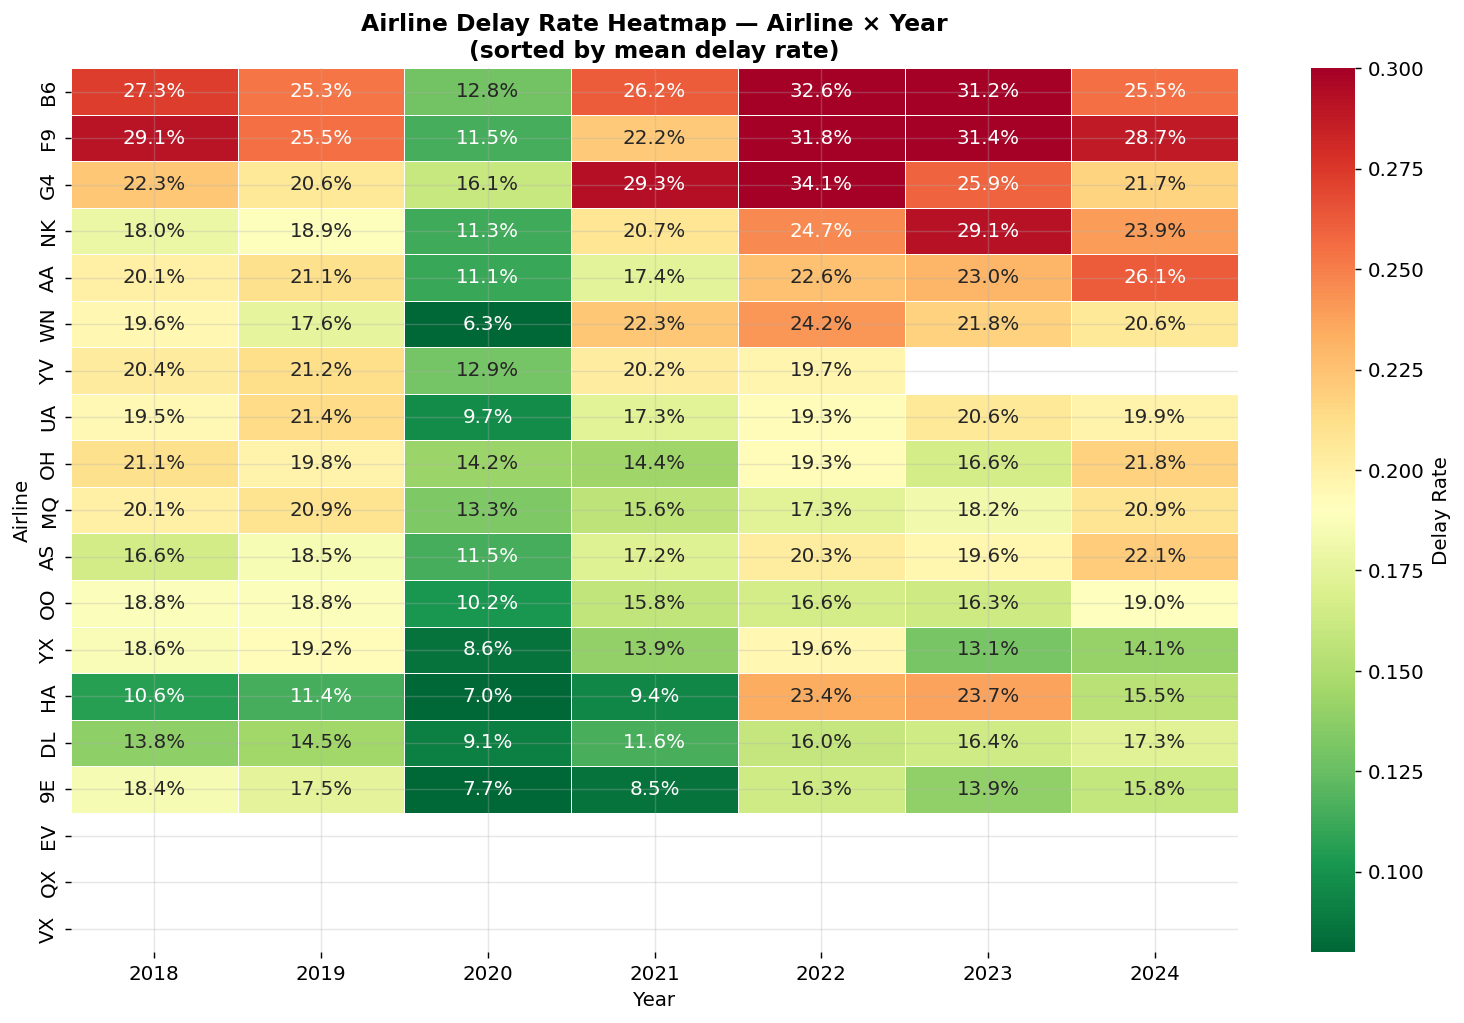

In [43]:
# Select airlines with consistent presence (>= 5 years of data)
airline_yr_cnt = df.groupby('Reporting_Airline')['Year'].nunique()
top_airlines   = airline_yr_cnt[airline_yr_cnt >= 5].index.tolist()

airline_yr = (
    df[df['Reporting_Airline'].isin(top_airlines)]
      .groupby(['Reporting_Airline','Year'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

# 10a. Heatmap: airline × year
al_pivot = airline_yr.pivot(index='Reporting_Airline',
                             columns='Year',
                             values='delay_rate')
# Sort by mean delay rate (worst to best)
al_pivot = al_pivot.loc[al_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, max(6, len(top_airlines)*0.5)))
sns.heatmap(
    al_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'RdYlGn_r',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.08,
    vmax     = 0.30,
)
ax.set_title('Airline Delay Rate Heatmap — Airline × Year\n(sorted by mean delay rate)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Airline')

plt.tight_layout()
plt.savefig('fig_11a_airline_heatmap.png', bbox_inches='tight')
plt.show()

/var/folders/s0/7__mncx10v9f5d7lh_jsd3d00000gn/T/ipykernel_42280/963936920.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Reporting_Airline')['ArrDel15']


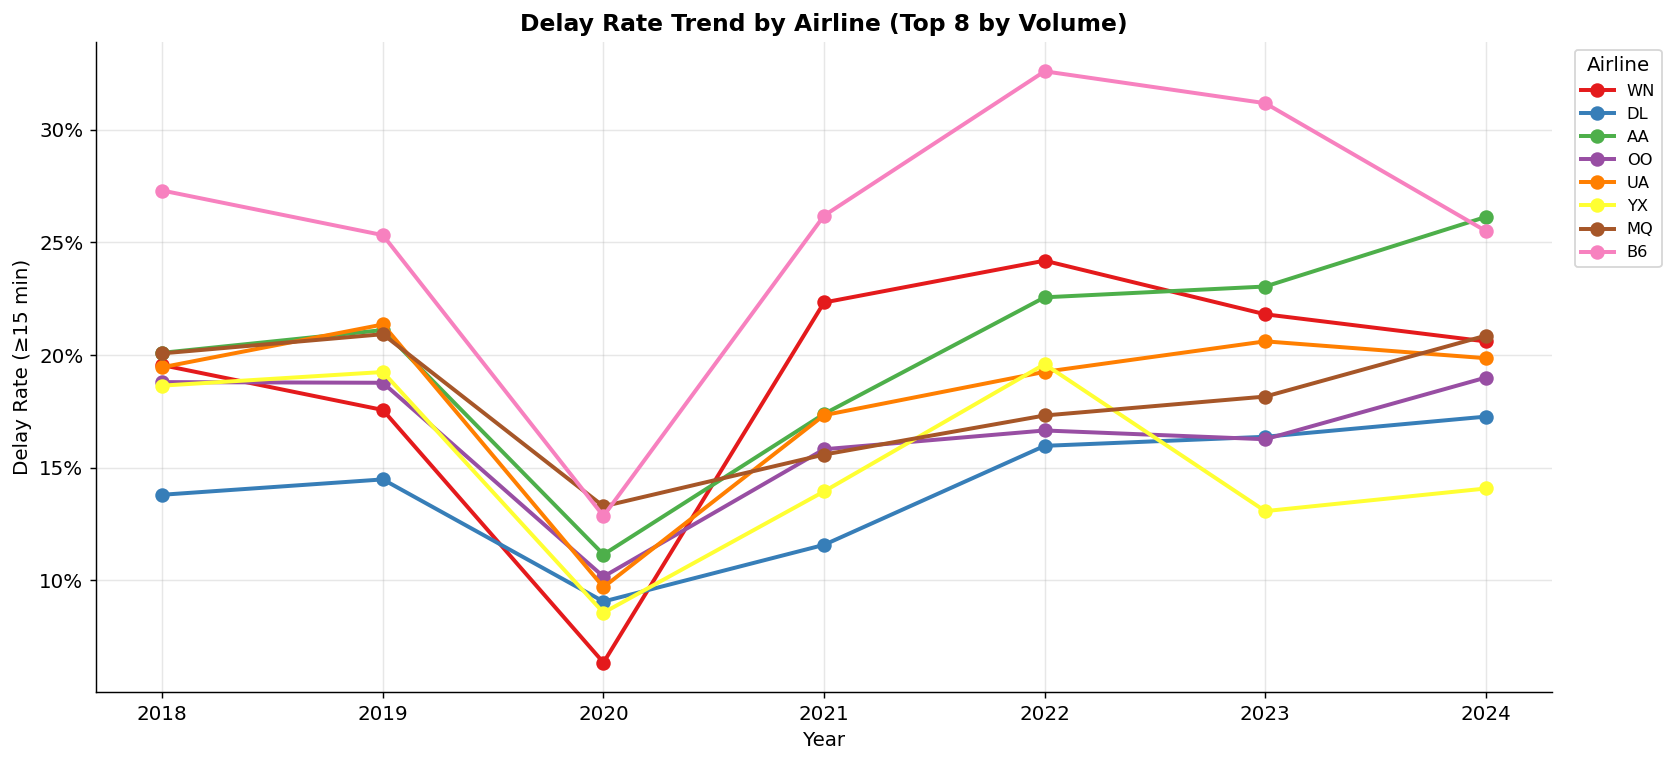

In [44]:
# 10b. Line chart: airline delay rate trends over years
# Select top 8 airlines by flight volume for readability
top8 = (
    df[df['Reporting_Airline'].isin(top_airlines)]
      .groupby('Reporting_Airline')['ArrDel15']
      .count()
      .nlargest(8)
      .index.tolist()
)

al_palette = dict(zip(top8, sns.color_palette('Set1', len(top8))))

fig, ax = plt.subplots(figsize=(13, 6))
for al in top8:
    sub = airline_yr[airline_yr['Reporting_Airline'] == al].sort_values('Year')
    ax.plot(sub['Year'], sub['delay_rate'],
            label=al, color=al_palette[al],
            linewidth=2.2, marker='o', markersize=7)

pct_fmt(ax)
ax.set_xticks(YEARS)
ax.set_title('Delay Rate Trend by Airline (Top 8 by Volume)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Airline', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_11b_airline_trends.png', bbox_inches='tight')
plt.show()

In [45]:
print('   Airline is a strong categorical feature.')
print('   Some carriers show persistent above-average delays; others improved or saw collapse in delay prevention post-COVID.')
print('   We could consider airline-level rolling delay rate as an engineered feature for the model.')

   Airline is a strong categorical feature.
   Some carriers show persistent above-average delays; others improved or saw collapse in delay prevention post-COVID.
   We could consider airline-level rolling delay rate as an engineered feature for the model.


---
## Section 11 — Distance Group Temporal Patterns

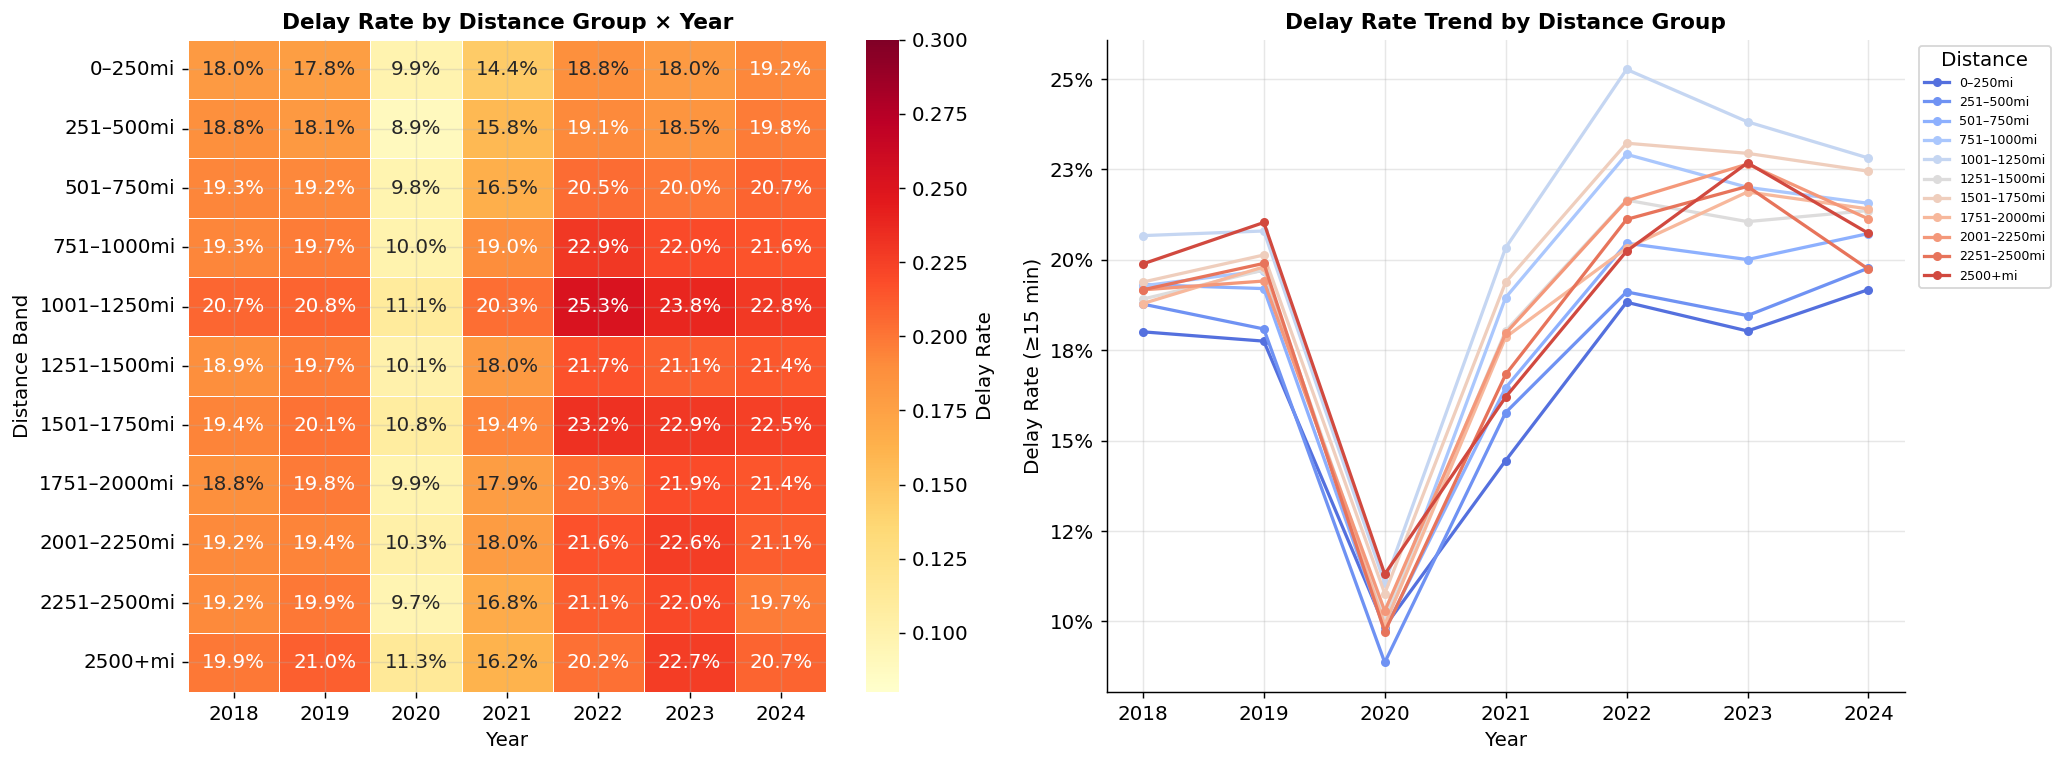

In [46]:
# Distance group labels (BTS definition: ~250mi bands)
dist_labels = {
    1:'0–250mi', 2:'251–500mi', 3:'501–750mi', 4:'751–1000mi',
    5:'1001–1250mi', 6:'1251–1500mi', 7:'1501–1750mi',
    8:'1751–2000mi', 9:'2001–2250mi', 10:'2251–2500mi', 11:'2500+mi'
}

dg = (
    df.groupby(['Year','DistanceGroup'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: distance group × year
ax = axes[0]
dg_pivot = dg.pivot(index='DistanceGroup', columns='Year', values='delay_rate')
dg_pivot.index = [dist_labels.get(i, str(i)) for i in dg_pivot.index]
sns.heatmap(
    dg_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'YlOrRd',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.08,
    vmax     = 0.30,
)
ax.set_title('Delay Rate by Distance Group × Year',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Distance Band')

# Line: delay rate by distance group per year
ax = axes[1]
dg_palette = sns.color_palette('coolwarm', 11)
for grp in sorted(dg['DistanceGroup'].unique()):
    sub = dg[dg['DistanceGroup'] == grp].sort_values('Year')
    ax.plot(sub['Year'], sub['delay_rate'],
            label=dist_labels.get(grp, str(grp)),
            color=dg_palette[grp - 1], linewidth=1.8, marker='o', markersize=4)

pct_fmt(ax)
ax.set_xticks(YEARS)
ax.set_title('Delay Rate Trend by Distance Group',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Distance', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig('fig_12_distance_group.png', bbox_inches='tight')
plt.show()

In [47]:
print('   Short-haul flights (0–500mi) tend to have lower delay rates')
print('   the worst rates appear in the middle and longer distance bands.')

   Short-haul flights (0–500mi) tend to have lower delay rates
   the worst rates appear in the middle and longer distance bands.


---
## Section 12 — Weather Condition Delay Rates by Year

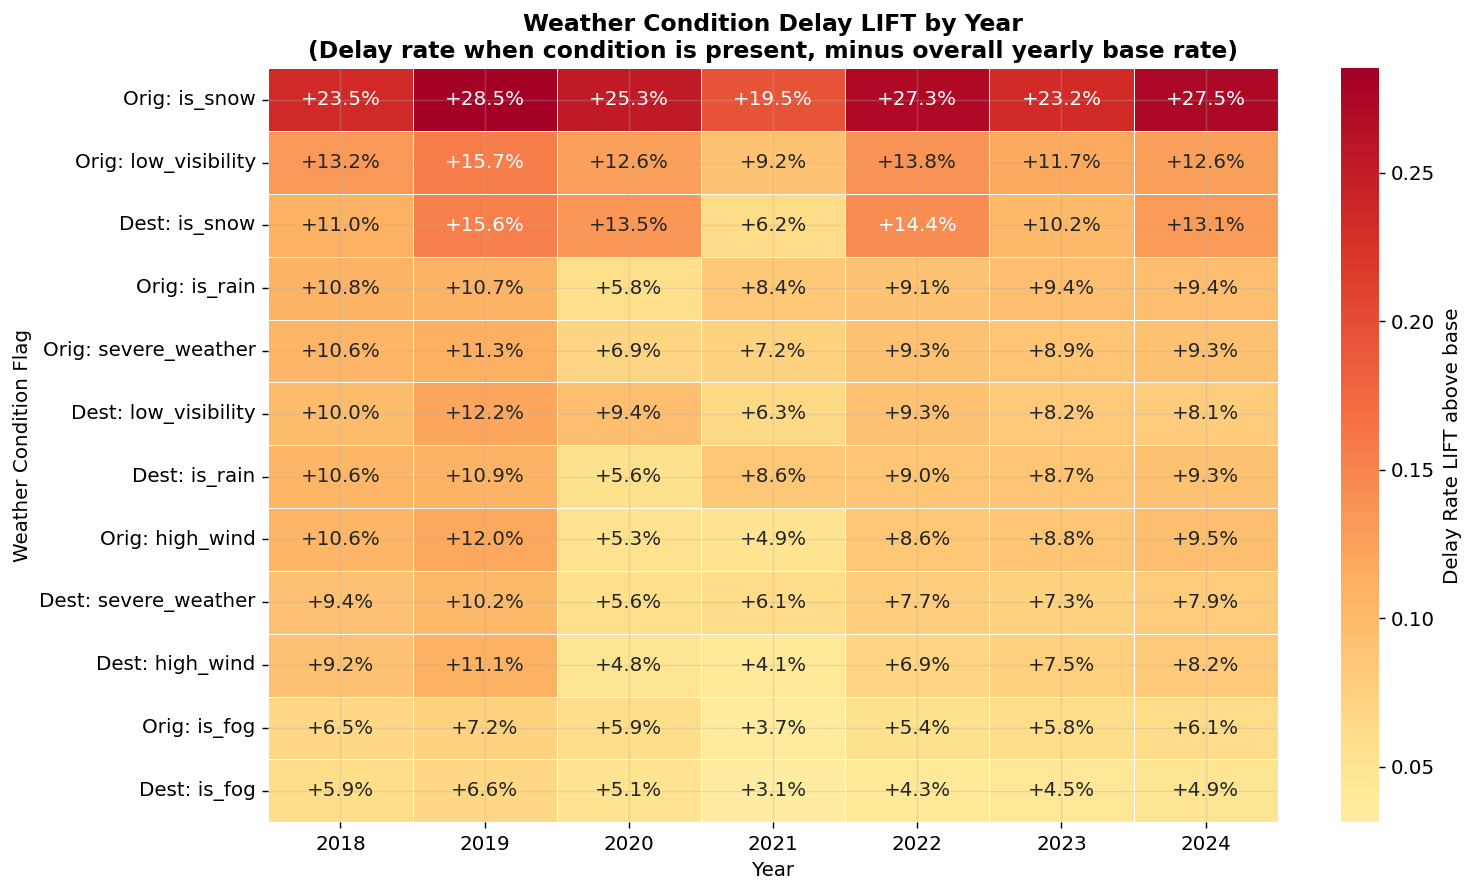

In [48]:
# Weather condition flag columns
wx_flags = [
    'origin_is_rain', 'origin_is_snow', 'origin_is_fog',
    'origin_low_visibility', 'origin_high_wind', 'origin_severe_weather',
    'dest_is_rain', 'dest_is_snow', 'dest_is_fog',
    'dest_low_visibility', 'dest_high_wind', 'dest_severe_weather',
]
wx_flags_present = [c for c in wx_flags if c in df.columns]

records = []
for col in wx_flags_present:
    for year in YEARS:
        sub = df[(df['Year'] == year) & df[col].notna()]
        records.append({
            'flag'      : col.replace('origin_','Orig: ').replace('dest_','Dest: '),
            'year'      : year,
            'delay_rate': sub.loc[sub[col] == 1, 'ArrDel15'].mean(),
            'base_rate' : sub['ArrDel15'].mean(),
        })

wx_df = pd.DataFrame(records)
wx_df['lift'] = wx_df['delay_rate'] - wx_df['base_rate']

# Heatmap: weather flag × year, colored by LIFT (delta above base rate)
lift_pivot = wx_df.pivot(index='flag', columns='year', values='lift')
# Sort by mean lift
lift_pivot = lift_pivot.loc[lift_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    lift_pivot,
    annot    = True,
    fmt      = '+.1%',
    cmap     = 'RdYlGn_r',
    center   = 0,
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate LIFT above base'},
)
ax.set_title(
    'Weather Condition Delay LIFT by Year\n'
    '(Delay rate when condition is present, minus overall yearly base rate)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('Weather Condition Flag')

plt.tight_layout()
plt.savefig('fig_13_weather_lift_heatmap.png', bbox_inches='tight')
plt.show()

In [49]:
print('   Positive lift = the condition is associated with higher delay probability.')
print('   Snow and low-visibility show the highest and most stable lifts across years.')
print('   Destination weather lift is often weaker but still potentially significant as strong lifts can be seen — both are needed for T-2h features.')

   Positive lift = the condition is associated with higher delay probability.
   Snow and low-visibility show the highest and most stable lifts across years.
   Destination weather lift is often weaker but still potentially significant as strong lifts can be seen — both are needed for T-2h features.


---
## Section 13 — Rolling 4-Week Delay Rate (Full 2018–2024 Trend)

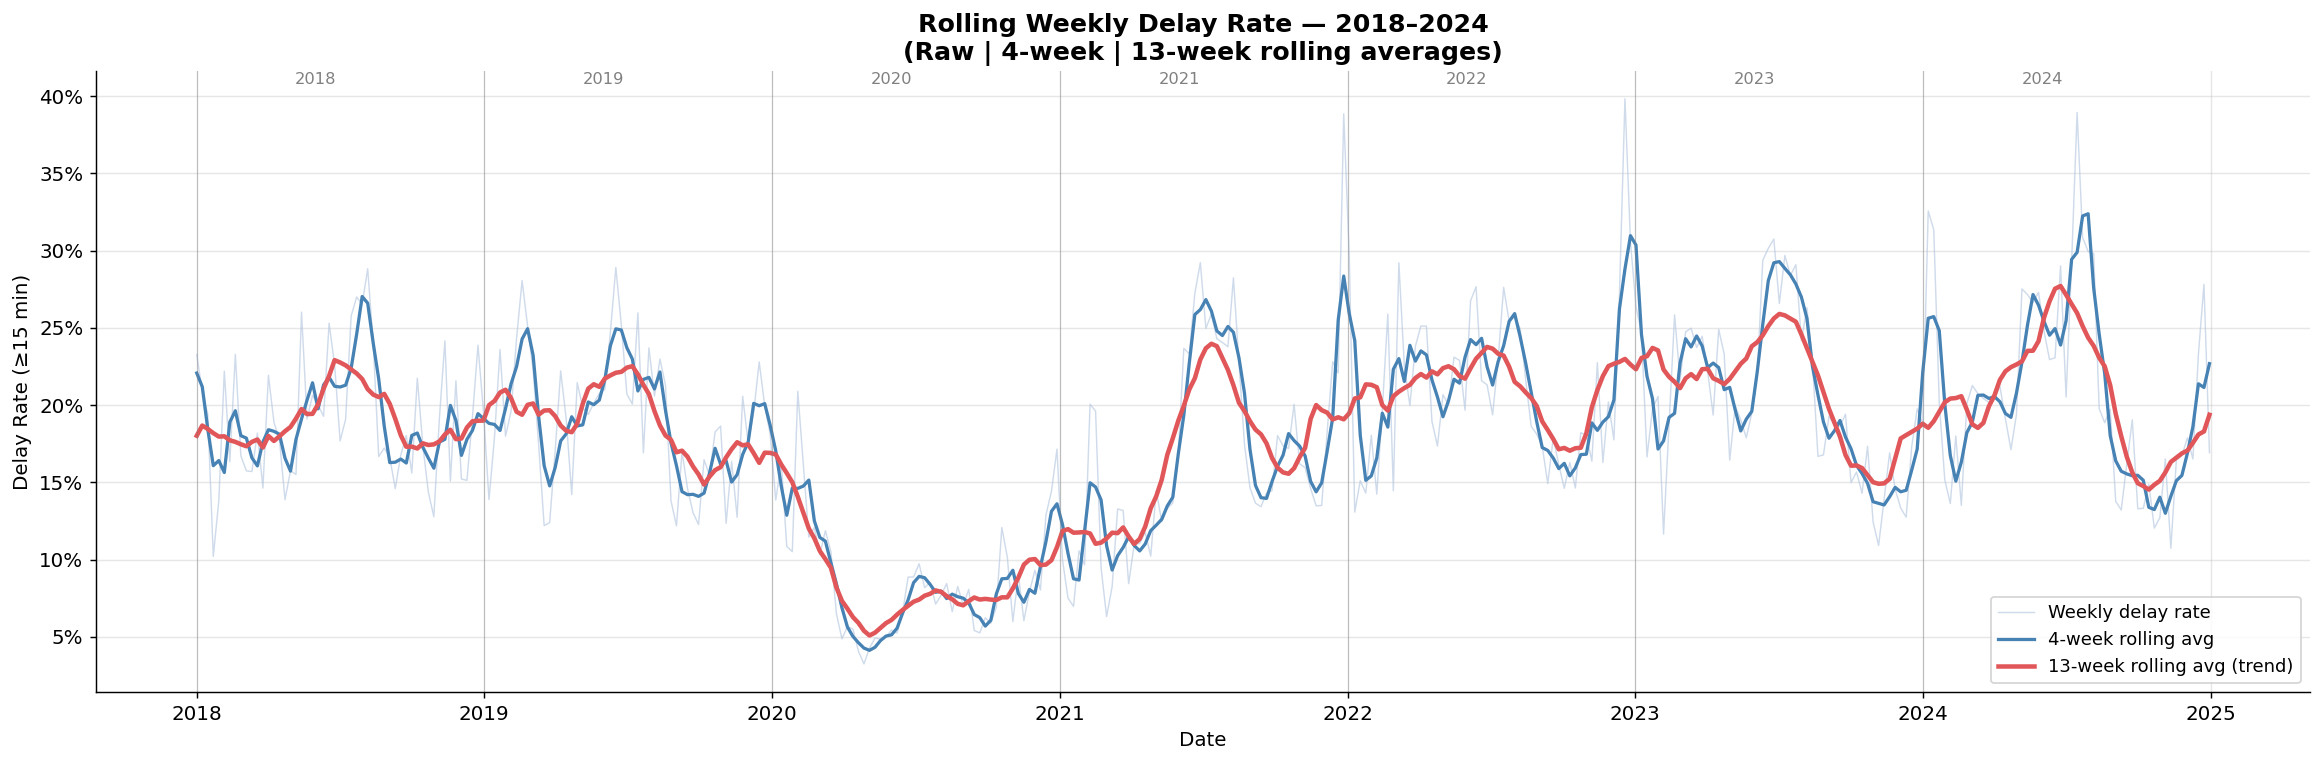

In [50]:
# Compute weekly delay rate
weekly = (
    df.groupby(df['FlightDate'].dt.to_period('W'))['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)
weekly['period_dt']     = weekly['FlightDate'].dt.start_time
weekly['rolling4w']     = weekly['delay_rate'].rolling(4, center=True, min_periods=2).mean()
weekly['rolling13w']    = weekly['delay_rate'].rolling(13, center=True, min_periods=4).mean()

fig, ax = plt.subplots(figsize=(18, 6))

# Raw weekly
ax.plot(weekly['period_dt'], weekly['delay_rate'],
        color='lightsteelblue', linewidth=0.8, alpha=0.6, label='Weekly delay rate')
# 4-week rolling
ax.plot(weekly['period_dt'], weekly['rolling4w'],
        color='steelblue', linewidth=1.8, label='4-week rolling avg')
# 13-week (quarterly) rolling
ax.plot(weekly['period_dt'], weekly['rolling13w'],
        color='#e15759', linewidth=2.5, label='13-week rolling avg (trend)')

# Year separators
for yr in range(2018, 2025):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
               linestyle='-', linewidth=0.6, alpha=0.4)
    ax.text(pd.Timestamp(f'{yr}-06-01'), ax.get_ylim()[1] * 0.98,
            str(yr), ha='center', fontsize=9, color='gray')

pct_fmt(ax)
ax.set_title('Rolling Weekly Delay Rate — 2018–2024\n'
             '(Raw | 4-week | 13-week rolling averages)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig_14_rolling_trend.png', bbox_inches='tight')
plt.show()

In [51]:
print('   The 13-week trend line clearly shows:')
print('   1. Stable ~20% (+-3) baseline pre-COVID (2018–2019)')
print('   2. Hard COVID plunge (2020 Q2)')
print('   3. Elevated post-COVID regime (2021–2024 settling again around ~20% but with very increased fluctuation)')
print('   ➡  Train-test split should probably be performed temporally, NOT randomly.')

   The 13-week trend line clearly shows:
   1. Stable ~20% (+-3) baseline pre-COVID (2018–2019)
   2. Hard COVID plunge (2020 Q2)
   3. Elevated post-COVID regime (2021–2024 settling again around ~20% but with very increased fluctuation)
   ➡  Train-test split should probably be performed temporally, NOT randomly.


---
## Section 14 — Seasonal Decomposition (STL)

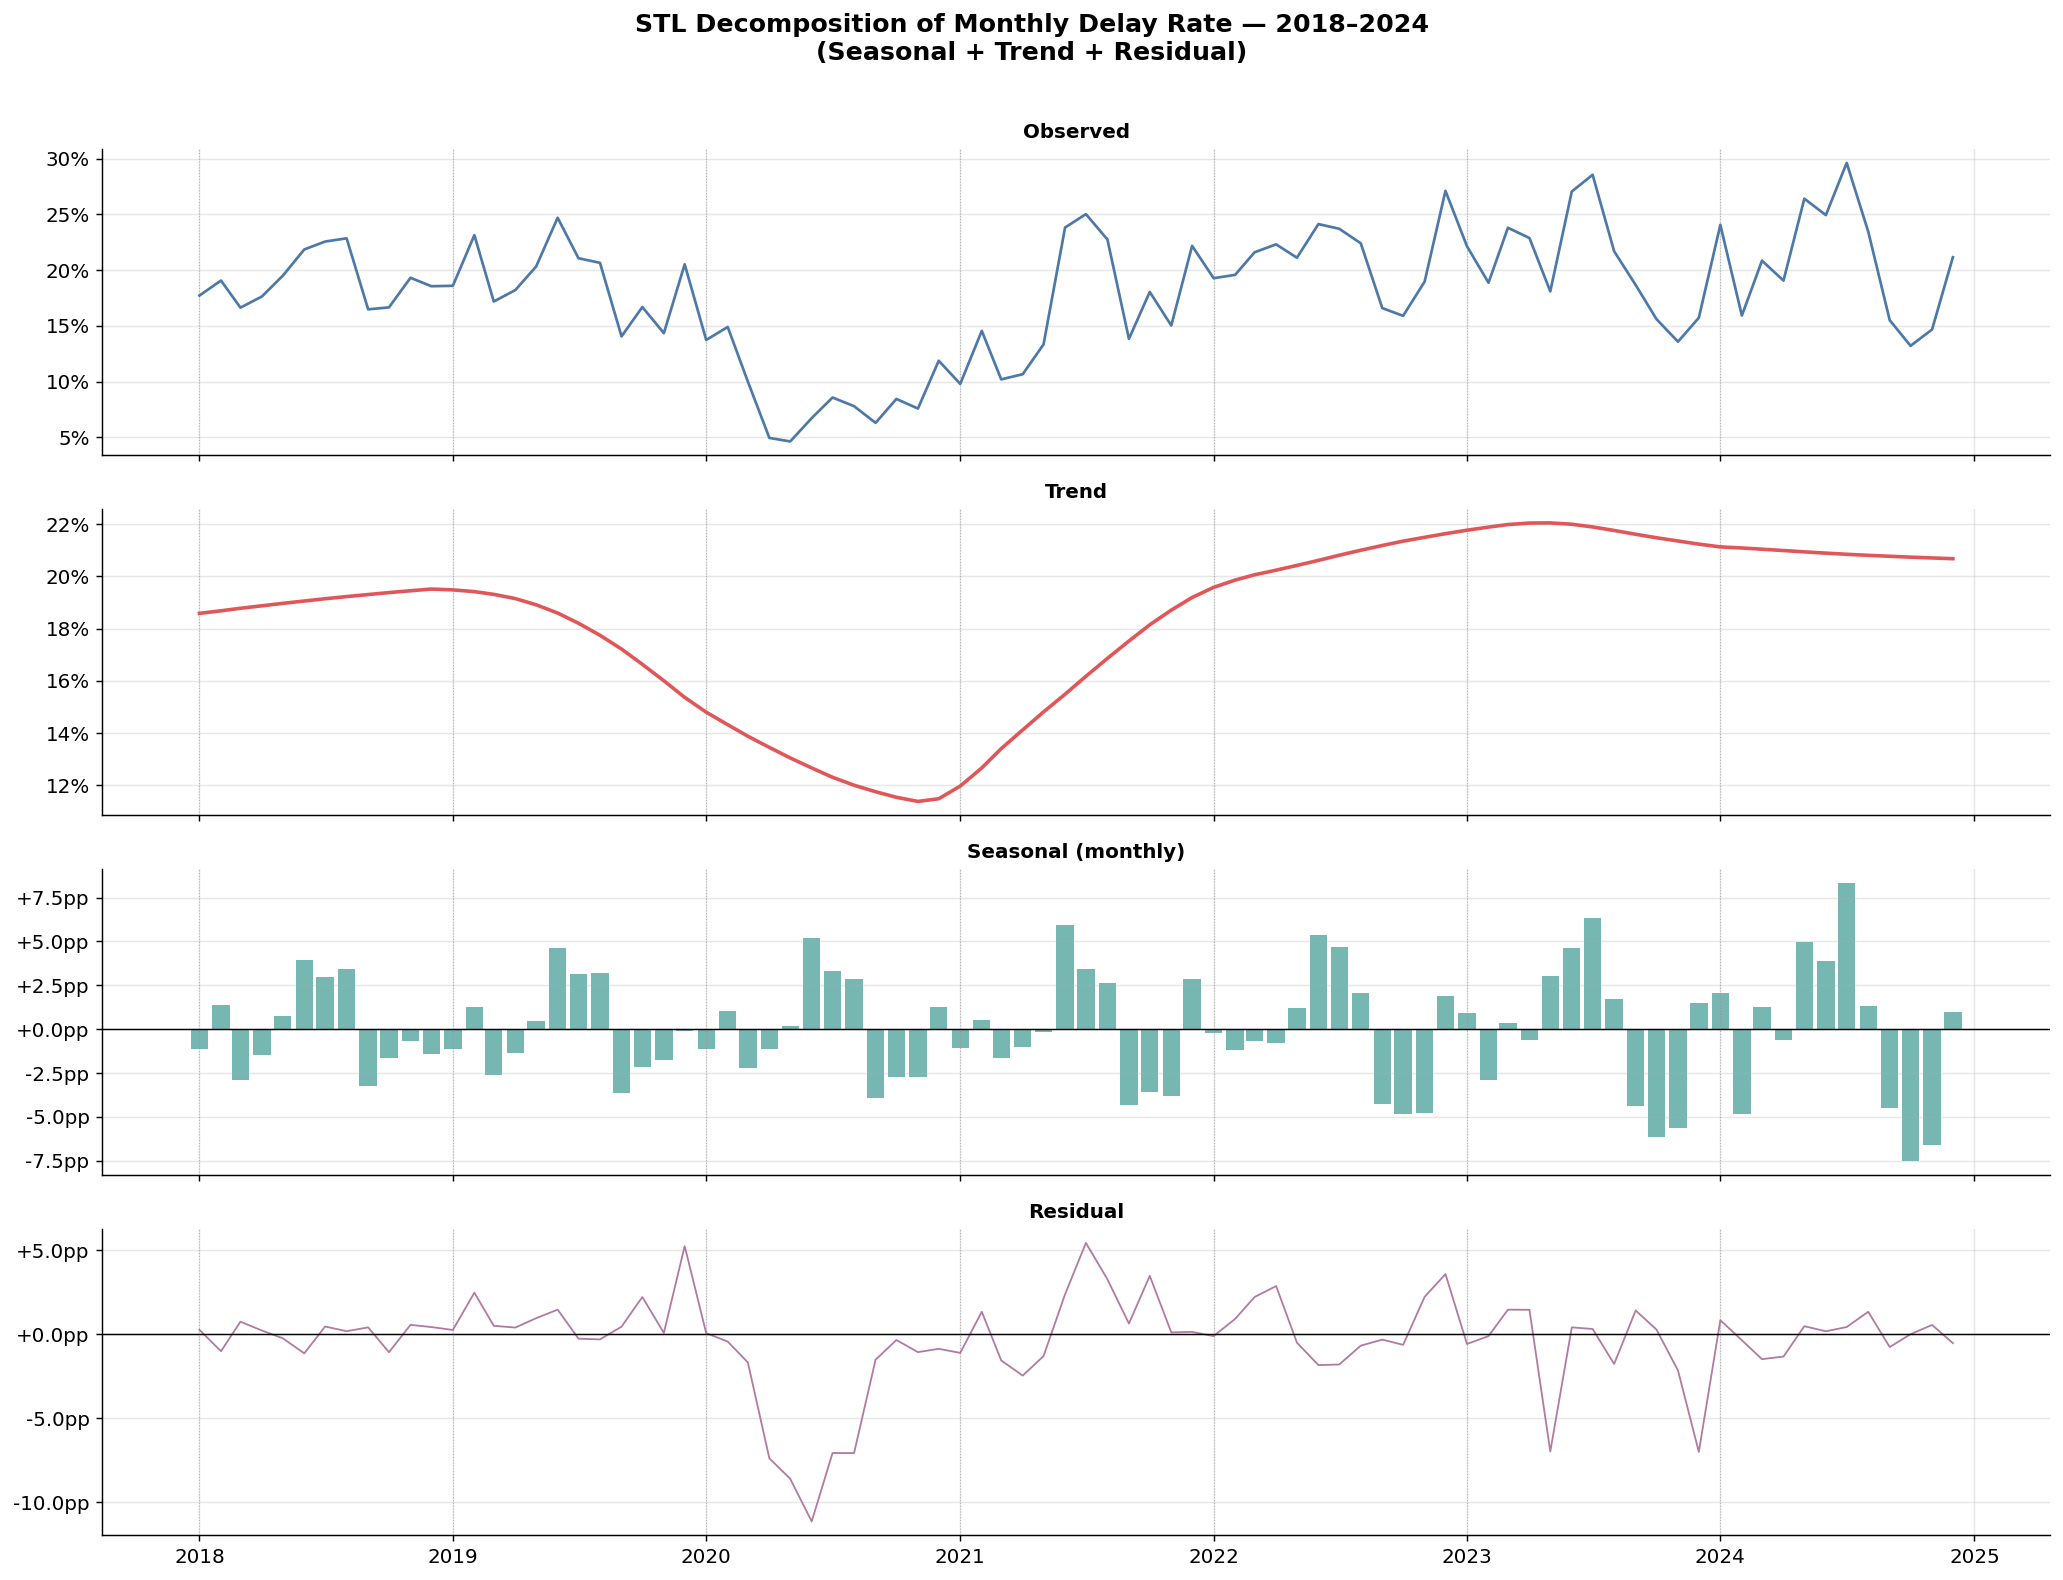

  Seasonal Strength (F_s): 0.590
   Values > 0.64 indicate strong seasonality (Wang et al. 2006).
   Average Monthly Seasonal Effect (percentage points vs trend):
   Jan: -0.24 pp  ↓
   Feb: -0.68 pp  ▓↓
   Mar: -1.21 pp  ▓▓↓
   Apr: -1.00 pp  ▓▓↓
   May: +1.48 pp  ▓▓↑
   Jun: +4.79 pp  ▓▓▓▓▓▓▓▓▓↑
   Jul: +4.60 pp  ▓▓▓▓▓▓▓▓▓↑
   Aug: +2.46 pp  ▓▓▓▓↑
   Sep: -4.05 pp  ▓▓▓▓▓▓▓▓↓
   Oct: -4.11 pp  ▓▓▓▓▓▓▓▓↓
   Nov: -3.71 pp  ▓▓▓▓▓▓▓↓
   Dec: +0.99 pp  ▓↑


In [52]:
try:
    from statsmodels.tsa.seasonal import STL

    # Monthly time series
    ts = (
        df.groupby(['Year','Month'])['ArrDel15']
          .mean()
          .reset_index()
    )
    ts['period'] = pd.to_datetime(
        ts['Year'].astype(str) + '-' + ts['Month'].astype(str).str.zfill(2) + '-01')
    ts = ts.sort_values('period').set_index('period')['ArrDel15']
    ts.index = pd.DatetimeIndex(ts.index, freq='MS')

    # Fit STL (period=12 for monthly data)
    stl    = STL(ts, period=12, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

    axes[0].plot(ts.index, ts.values,          color='#4e79a7', linewidth=1.5)
    axes[0].set_title('Observed',              fontsize=11, fontweight='bold')
    pct_fmt(axes[0])

    axes[1].plot(ts.index, result.trend,       color='#e15759', linewidth=2)
    axes[1].set_title('Trend',                 fontsize=11, fontweight='bold')
    pct_fmt(axes[1])

    axes[2].bar(ts.index, result.seasonal,     color='#76b7b2', width=25)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Seasonal (monthly)',    fontsize=11, fontweight='bold')
    axes[2].yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y*100:+.1f}pp'))

    axes[3].plot(ts.index, result.resid,       color='#b07aa1', linewidth=1)
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].set_title('Residual',              fontsize=11, fontweight='bold')
    axes[3].yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y*100:+.1f}pp'))

    for ax in axes:
        for yr in range(2018, 2025):
            ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
                       linestyle=':', linewidth=0.6, alpha=0.5)

    fig.suptitle('STL Decomposition of Monthly Delay Rate — 2018–2024\n'
                 '(Seasonal + Trend + Residual)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('fig_15_stl_decomposition.png', bbox_inches='tight')
    plt.show()

    # Seasonal strength
    var_seasonal = np.var(result.seasonal)
    var_residual = np.var(result.resid)
    strength_s   = max(0, 1 - var_residual / (var_seasonal + var_residual))
    print(f'  Seasonal Strength (F_s): {strength_s:.3f}')
    print('   Values > 0.64 indicate strong seasonality (Wang et al. 2006).')

    # Month seasonal components
    seasonal_mean = (
        pd.Series(result.seasonal.values, index=ts.index)
          .groupby(lambda x: x.month)
          .mean()
    )
    print('   Average Monthly Seasonal Effect (percentage points vs trend):')
    for m, v in seasonal_mean.items():
        bar = '▓' * int(abs(v) * 200) + ('↑' if v > 0 else '↓')
        print(f'   {MONTH_NAMES[m]:>3}: {v*100:+.2f} pp  {bar}')

except ImportError:
    print('   statsmodels not found. Install with:  pip install statsmodels')
    print('   Then re-run this cell for the STL decomposition.')

---
## Section 15 — Correlation Matrix: Temporal & Weather Features vs ArrDel15

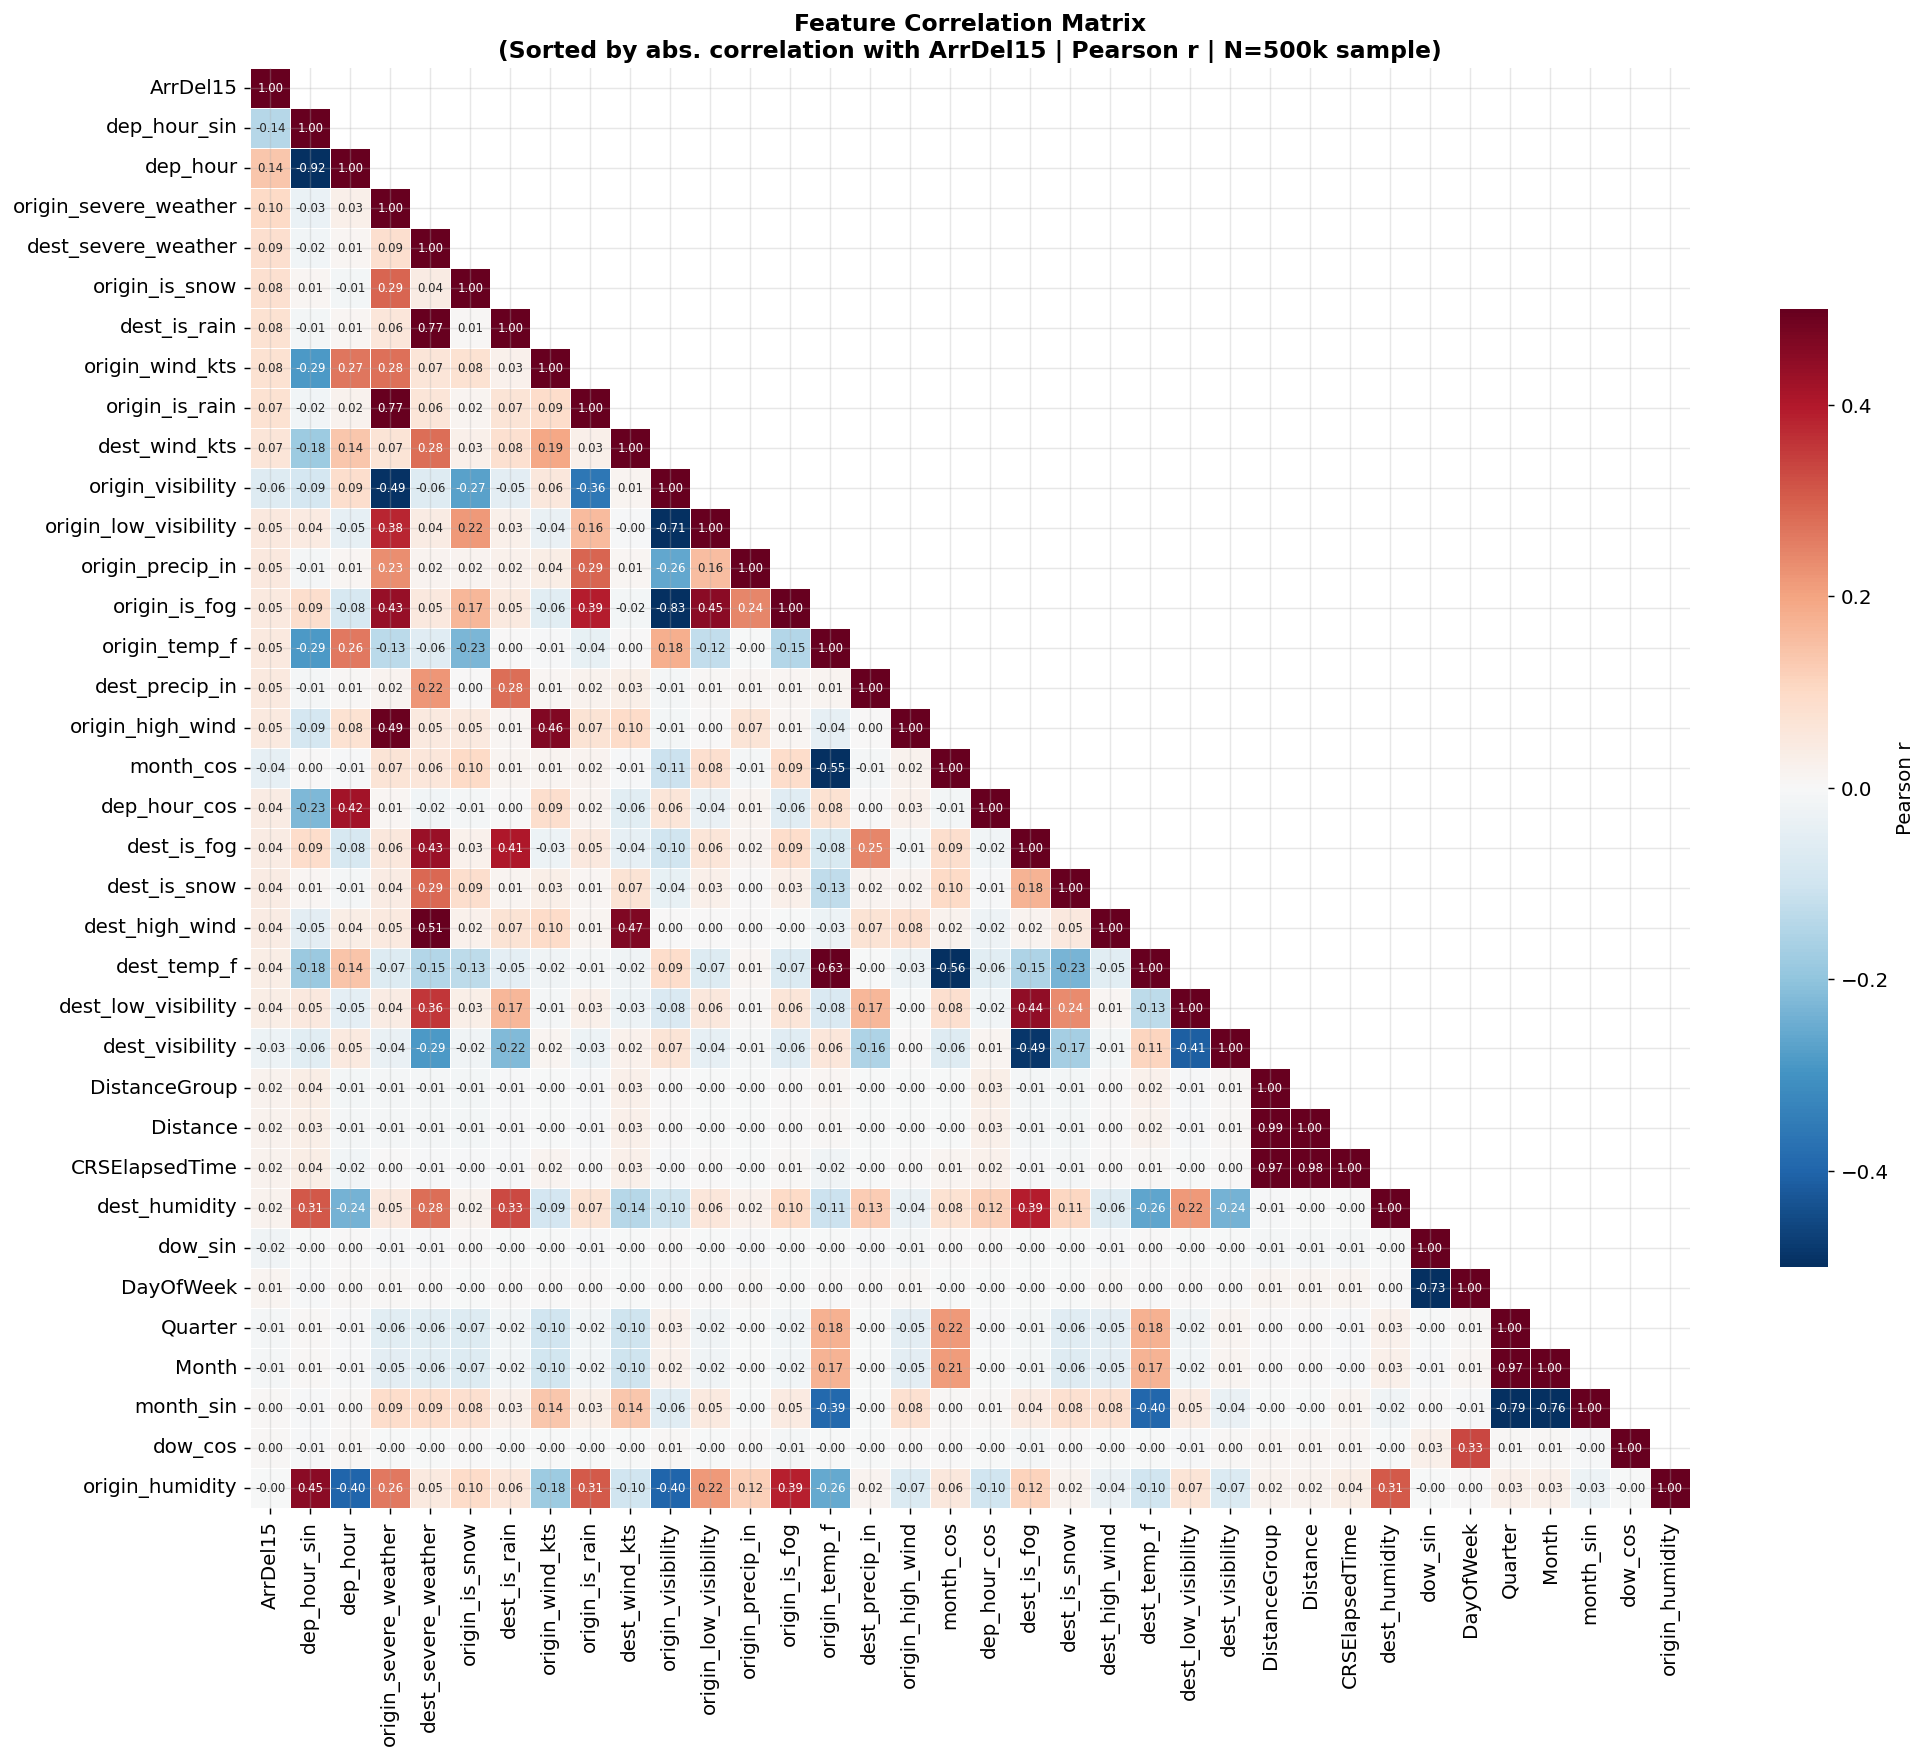

   Top 15 features by absolute Pearson correlation with ArrDel15:
─────────────────────────────────────────────
  dep_hour_sin                   +0.1425  ███████
  dep_hour                       +0.1391  ██████
  origin_severe_weather          +0.0988  ████
  dest_severe_weather            +0.0859  ████
  origin_is_snow                 +0.0791  ███
  dest_is_rain                   +0.0765  ███
  origin_wind_kts                +0.0760  ███
  origin_is_rain                 +0.0746  ███
  dest_wind_kts                  +0.0657  ███
  origin_visibility              +0.0648  ███
  origin_low_visibility          +0.0518  ██
  origin_precip_in               +0.0513  ██
  origin_is_fog                  +0.0506  ██
  origin_temp_f                  +0.0491  ██
  dest_precip_in                 +0.0484  ██


In [53]:
# Select numeric features available at T-2h
feature_cols = [
    'ArrDel15',
    # Temporal
    'Month', 'DayOfWeek', 'dep_hour', 'Quarter',
    # Flight
    'CRSElapsedTime', 'Distance', 'DistanceGroup',
    # Origin weather @ T-2h
    'origin_temp_f', 'origin_humidity', 'origin_wind_kts',
    'origin_visibility', 'origin_precip_in',
    'origin_is_rain', 'origin_is_snow', 'origin_is_fog',
    'origin_low_visibility', 'origin_high_wind', 'origin_severe_weather',
    # Destination weather @ T-2h
    'dest_temp_f', 'dest_humidity', 'dest_wind_kts',
    'dest_visibility', 'dest_precip_in',
    'dest_is_rain', 'dest_is_snow', 'dest_is_fog',
    'dest_low_visibility', 'dest_high_wind', 'dest_severe_weather',
]
feature_cols_present = [c for c in feature_cols if c in df.columns]

# Sample 500k rows for speed
rng    = np.random.default_rng(42)
idx    = rng.choice(len(df), size=min(500_000, len(df)), replace=False)
sample = df.iloc[idx][feature_cols_present].copy()

# Encode dep_hour as sin/cos cyclical features
sample['dep_hour_sin'] = np.sin(2 * np.pi * sample['dep_hour'] / 24)
sample['dep_hour_cos'] = np.cos(2 * np.pi * sample['dep_hour'] / 24)
sample['month_sin']    = np.sin(2 * np.pi * sample['Month'] / 12)
sample['month_cos']    = np.cos(2 * np.pi * sample['Month'] / 12)
sample['dow_sin']      = np.sin(2 * np.pi * sample['DayOfWeek'] / 7)
sample['dow_cos']      = np.cos(2 * np.pi * sample['DayOfWeek'] / 7)

corr = sample.corr(method='pearson', numeric_only=True)

# Sort features by absolute correlation with target
target_corr = corr['ArrDel15'].drop('ArrDel15').abs().sort_values(ascending=False)
ordered_cols = ['ArrDel15'] + target_corr.index.tolist()
corr_sorted  = corr.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.zeros_like(corr_sorted, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle only

sns.heatmap(
    corr_sorted,
    mask     = mask,
    annot    = True,
    fmt      = '.2f',
    cmap     = 'RdBu_r',
    center   = 0,
    vmin     = -0.5,
    vmax     = 0.5,
    linewidths = 0.3,
    ax       = ax,
    square   = True,
    cbar_kws = {'shrink': 0.6, 'label': 'Pearson r'},
    annot_kws= {'fontsize': 6.5},
)
ax.set_title(
    'Feature Correlation Matrix\n'
    '(Sorted by abs. correlation with ArrDel15 | Pearson r | N=500k sample)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_16_correlation_matrix.png', bbox_inches='tight')
plt.show()

print('   Top 15 features by absolute Pearson correlation with ArrDel15:')
print('─' * 45)
for feat, r in target_corr.head(15).items():
    bar = '█' * int(r * 50)
    print(f'  {feat:<30} {r:+.4f}  {bar}')

## Part 2: Categorical EDA

## Section 0: Setup & Data Loading

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

%matplotlib inline

print('All imports successful!')

All imports successful!


In [55]:
# Origin and Dest are read as object — convert to category for memory efficiency
# (Reporting_Airline, DepTimeBlk, FlightDate, ArrDel15 are already correctly typed in the parquet)
df[['Origin', 'Dest']] = df[['Origin', 'Dest']].astype('category')

print('Dtypes after conversion:')
print(df.dtypes)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Dtypes after conversion:
Year                                        int64
Quarter                                     int64
Month                                       int64
DayofMonth                                  int64
DayOfWeek                                   int64
FlightDate                         datetime64[ns]
Reporting_Airline                        category
Flight_Number_Reporting_Airline    string[python]
Origin                                   category
Dest                                     category
CRSDepTime                                  int64
DepTimeBlk                               category
CRSArrTime                                  int64
ArrDel15                                  float64
CRSElapsedTime                            float64
Distance                                  float64
DistanceGroup                               int64
date                                       object
dep_hour                                    Int64
arr_hour                 

## Section 1: Categorical Feature Analysis

In [56]:
# Show categorical columns and their unique value counts
cat_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique()
})
cat_summary = cat_summary[cat_summary['dtype'] == 'category']
cat_summary = cat_summary.sort_values('unique_values', ascending=False)

print('Categorical columns in the dataset:')
print(cat_summary)

Categorical columns in the dataset:
                      dtype  unique_values
Origin             category            384
Dest               category            384
Reporting_Airline  category             19
DepTimeBlk         category             19


In [57]:
print('Unique values in DepTimeBlk:')
print(sorted(df['DepTimeBlk'].unique()))

Unique values in DepTimeBlk:
['0001-0559', '0600-0659', '0700-0759', '0800-0859', '0900-0959', '1000-1059', '1100-1159', '1200-1259', '1300-1359', '1400-1459', '1500-1559', '1600-1659', '1700-1759', '1800-1859', '1900-1959', '2000-2059', '2100-2159', '2200-2259', '2300-2359']


### 1.1 Delay Rate by Airline

/var/folders/s0/7__mncx10v9f5d7lh_jsd3d00000gn/T/ipykernel_42280/3723812137.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Reporting_Airline')['ArrDel15']


   Reporting_Airline  Pct_Delayed
0                 9E        14.05
4                 DL        14.50
13                QX        14.60
8                 HA        15.16
18                YX        15.65
12                OO        16.75
9                 MQ        18.35
2                 AS        18.43
11                OH        18.47
14                UA        19.07
17                YV        19.32
16                WN        19.45
15                VX        20.05
1                 AA        20.93
5                 EV        21.42
10                NK        21.98
7                 G4        24.68
3                 B6        26.85
6                 F9        26.91


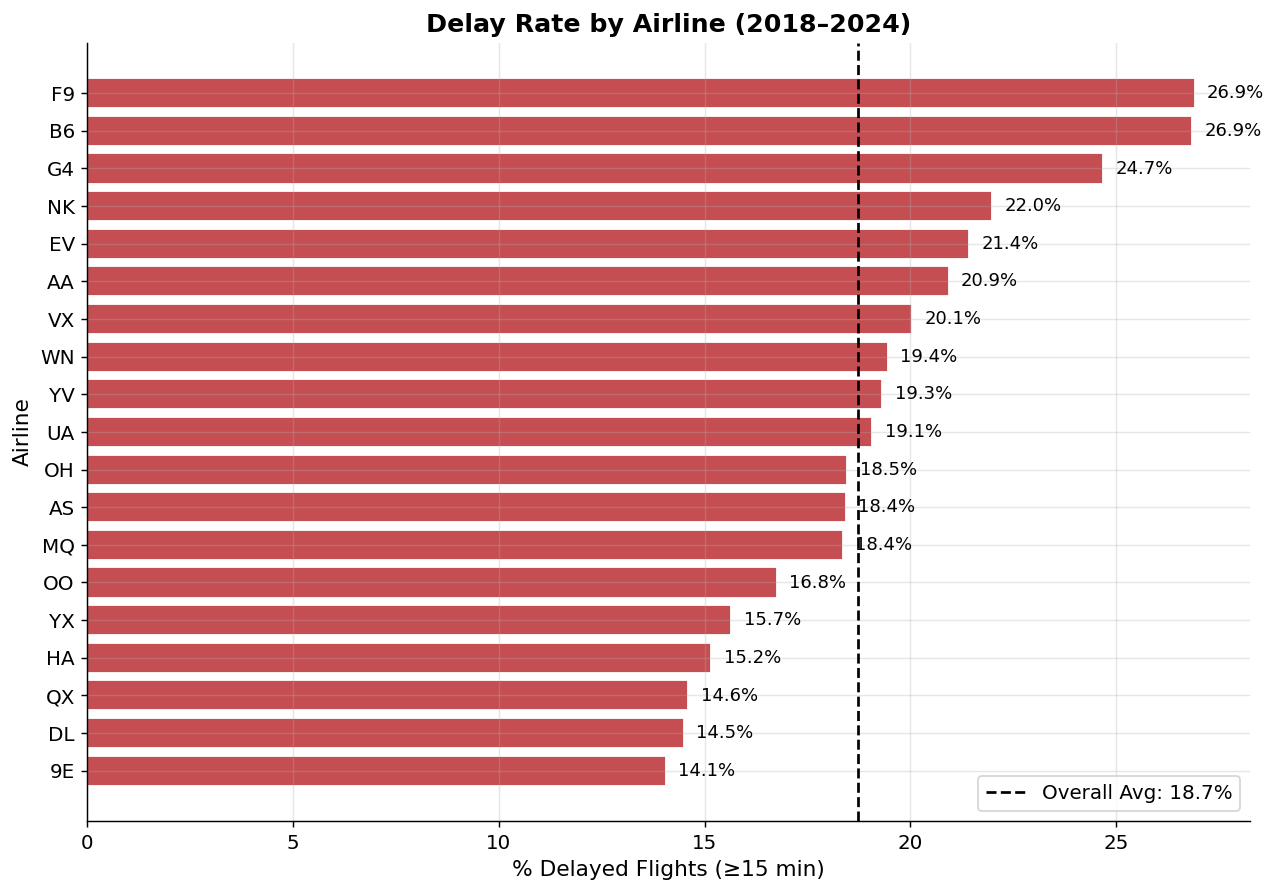

In [58]:
airline_delay = (
    df.groupby('Reporting_Airline')['ArrDel15']
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={'ArrDel15': 'Pct_Delayed'})
      .sort_values('Pct_Delayed', ascending=True)
)

print(airline_delay)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    airline_delay['Reporting_Airline'],
    airline_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white'
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

# Overall average line
overall_avg = df['ArrDel15'].mean() * 100
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Airline (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylabel('Airline', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Delay Rate by Origin Airport (Top 20 by Volume)

   Origin  Pct_Delayed
19    SLC        14.74
14    MSP        15.68
6     DTW        15.85
0     ATL        16.30
11    LAX        16.87
17    SEA        17.45
16    PHX        17.80
18    SFO        18.82
3     DCA        18.85
8     IAH        19.17
12    LGA        19.91
1     BOS        20.16
2     CLT        20.36
9     JFK        20.88
10    LAS        21.24
15    ORD        21.78
4     DEN        22.00
5     DFW        22.54
13    MCO        23.17
7     EWR        23.53


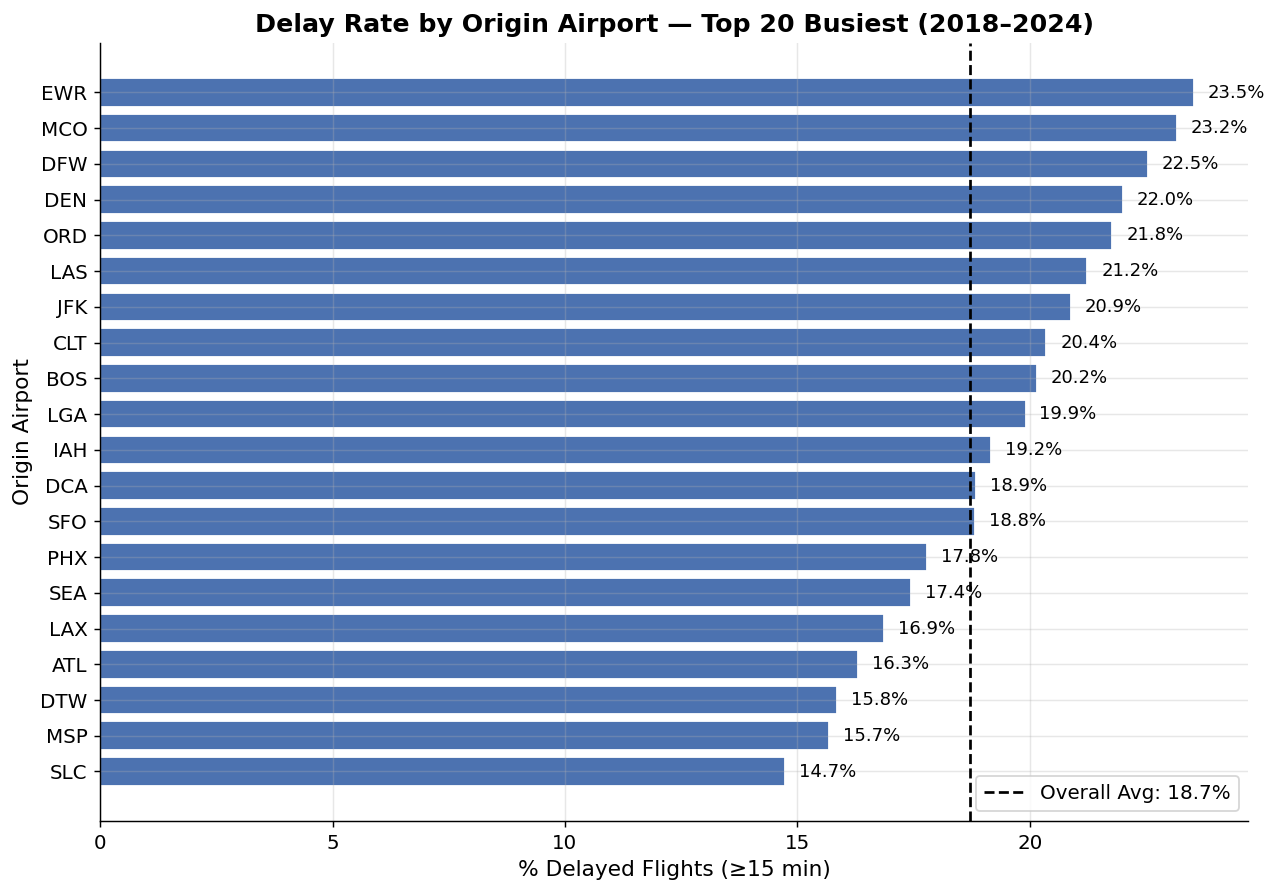

In [59]:
# Get top 20 busiest origin airports by flight volume
top20_origins = df['Origin'].value_counts().head(20).index

origin_delay = (
    df[df['Origin'].isin(top20_origins)]
    .dropna(subset=['ArrDel15'])
    .groupby('Origin', observed=True)['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
    .sort_values('Pct_Delayed', ascending=True)
)

origin_delay['Pct_Delayed'] = origin_delay['Pct_Delayed'].astype(float)

print(origin_delay)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    origin_delay['Origin'].astype(str),
    origin_delay['Pct_Delayed'],
    color='#4c72b0',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Origin Airport — Top 20 Busiest (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylabel('Origin Airport', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_origin.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Delay Rate by Destination Airport (Top 20 by Volume)

   Dest  Pct_Delayed
19  SLC        13.91
14  MSP        14.43
0   ATL        14.49
6   DTW        14.74
2   CLT        16.58
17  SEA        16.99
16  PHX        17.59
11  LAX        17.87
8   IAH        18.04
4   DEN        18.36
3   DCA        18.84
15  ORD        18.90
5   DFW        20.09
10  LAS        20.70
9   JFK        21.21
12  LGA        21.36
1   BOS        21.74
18  SFO        22.13
13  MCO        22.62
7   EWR        24.89


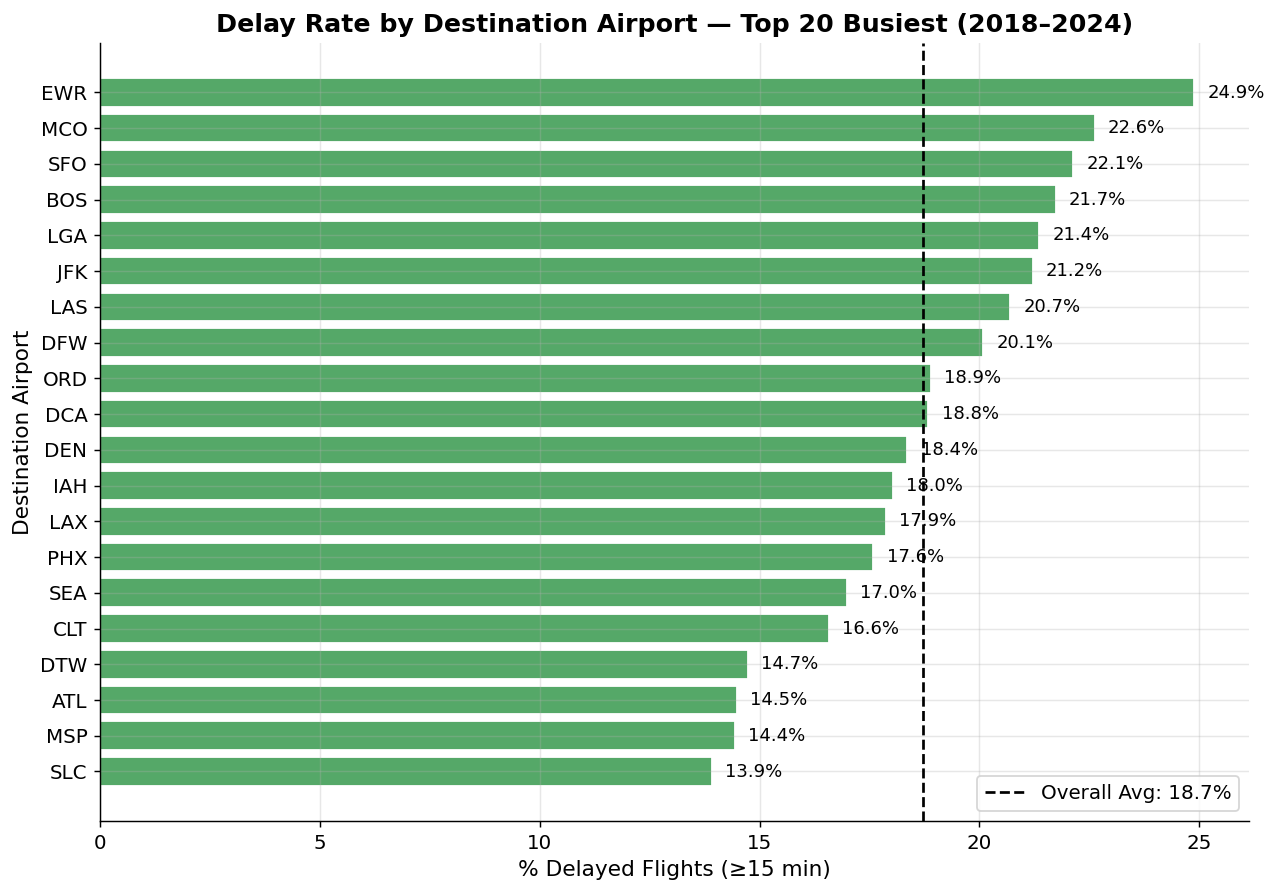

In [60]:
# Get top 20 busiest destination airports by flight volume
top20_dests = df['Dest'].value_counts().head(20).index

dest_delay = (
    df[df['Dest'].isin(top20_dests)]
    .dropna(subset=['ArrDel15'])
    .groupby('Dest', observed=True)['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
    .sort_values('Pct_Delayed', ascending=True)
)

dest_delay['Pct_Delayed'] = dest_delay['Pct_Delayed'].astype(float)

print(dest_delay)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    dest_delay['Dest'].astype(str),
    dest_delay['Pct_Delayed'],
    color='#55a868',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Destination Airport — Top 20 Busiest (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylabel('Destination Airport', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_dest.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 1 — Key Findings: Categorical Feature Analysis

- Delay rates vary significantly across airlines (14.1% to 26.9%) and airports (13.9% to 24.9%), confirming both are strong predictors of delay.
- EWR (Newark) is the worst airport in both origin and destination charts, while NYC-area airports (EWR, LGA, JFK) consistently rank above the overall average — likely driven by airspace congestion.
- With 384 unique airports, one-hot encoding is impractical; target encoding is recommended, while `Reporting_Airline` (19 values) can be safely one-hot encoded.

## Section 2: Temporal Feature Analysis

### 2.1 Delay Rate by Hour of Day

    dep_hour  Pct_Delayed
0          0        18.08
1          1        18.65
2          2        23.30
3          3        23.27
4          4        19.73
5          5         8.47
6          6         9.42
7          7        11.51
8          8        12.96
9          9        14.01
10        10        15.11
11        11        15.94
12        12        17.52
13        13        19.10
14        14        20.89
15        15        22.18
16        16        23.72
17        17        24.41
18        18        25.77
19        19        26.26
20        20        26.17
21        21        26.01
22        22        24.12
23        23        20.44
24        24         0.00


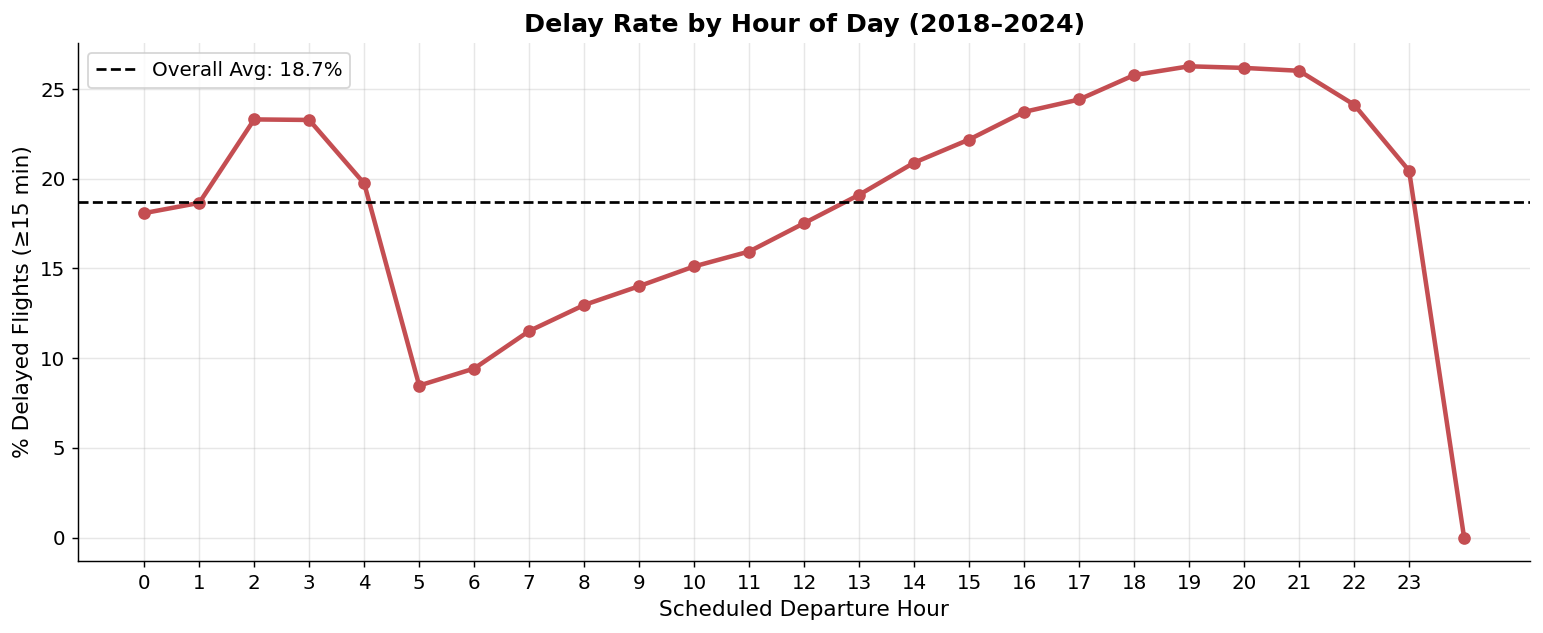

In [61]:
# dep_hour is pre-computed in the dataset (= CRSDepTime // 100)
hour_delay = (
    df.dropna(subset=['ArrDel15'])
    .groupby('dep_hour')['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

hour_delay['Pct_Delayed'] = hour_delay['Pct_Delayed'].astype(float)

print(hour_delay)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    hour_delay['dep_hour'],
    hour_delay['Pct_Delayed'],
    color='#c44e52',
    linewidth=2.5,
    marker='o',
    markersize=6
)

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Hour of Day (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Delay Rate by Day of Week

   Day  Pct_Delayed
0  Mon        18.98
1  Tue        16.70
2  Wed        17.25
3  Thu        19.91
4  Fri        20.58
5  Sat        17.66
6  Sun        19.61


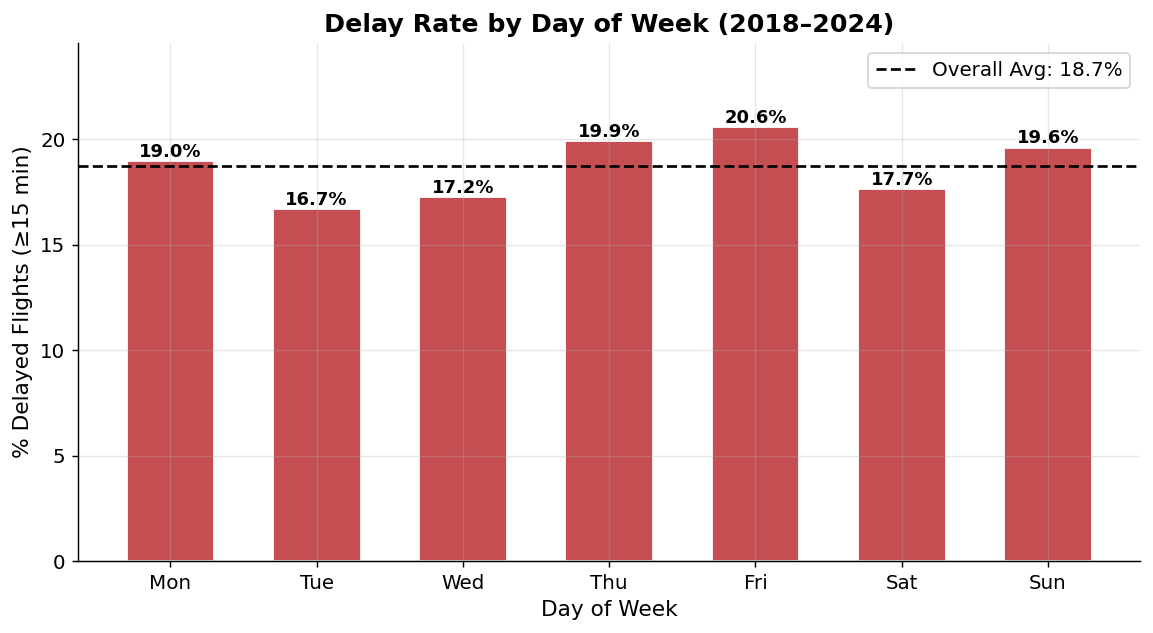

In [62]:
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}

dow_delay = (
    df.dropna(subset=['ArrDel15'])
    .groupby('DayOfWeek')['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

dow_delay['Pct_Delayed'] = dow_delay['Pct_Delayed'].astype(float)
dow_delay['Day'] = dow_delay['DayOfWeek'].map(day_names)

print(dow_delay[['Day', 'Pct_Delayed']])

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    dow_delay['Day'],
    dow_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Day of Week (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylim(0, dow_delay['Pct_Delayed'].max() + 4)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_dow.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Delay Rate by Month

   MonthName  Pct_Delayed
0        Jan        18.19
1        Feb        18.13
2        Mar        17.47
3        Apr        17.96
4        May        19.28
5        Jun        23.34
6        Jul        23.59
7        Aug        20.92
8        Sep        15.03
9        Oct        15.31
10       Nov        15.16
11       Dec        19.91


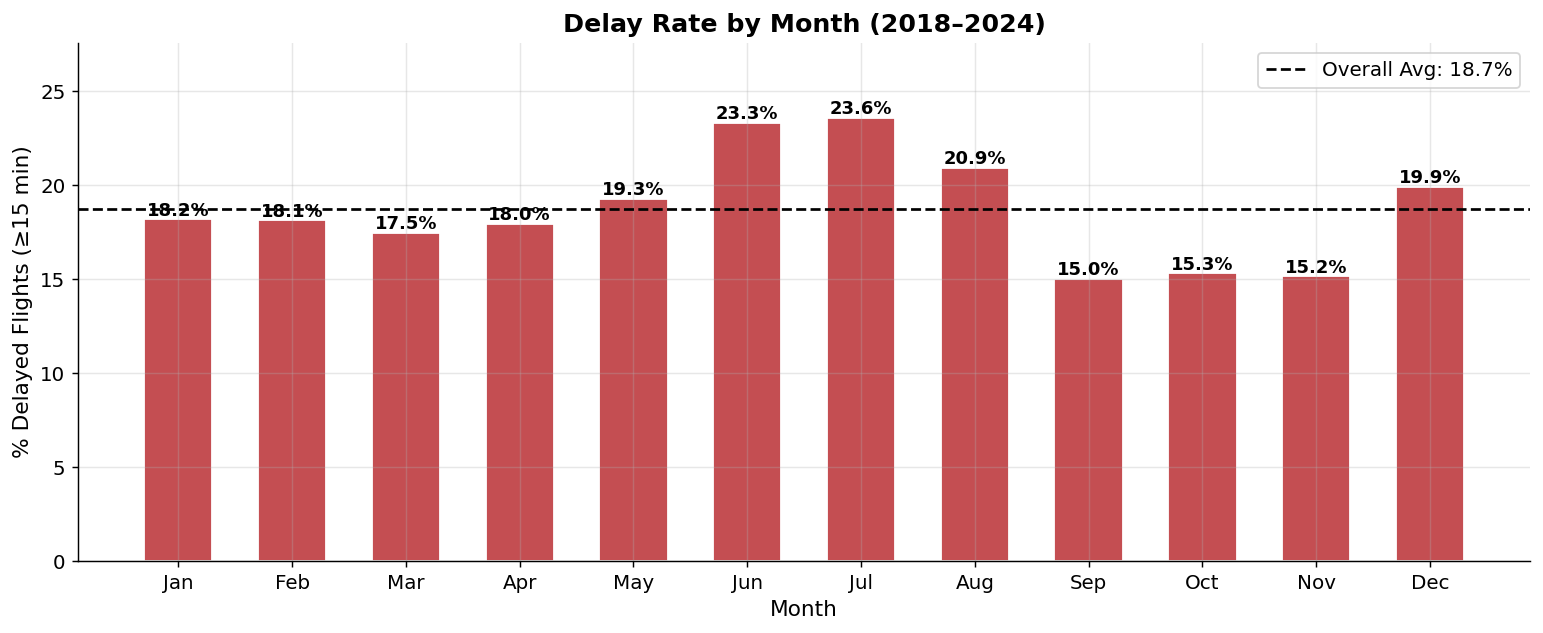

In [63]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

month_delay = (
    df.dropna(subset=['ArrDel15'])
    .groupby('Month')['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

month_delay['Pct_Delayed'] = month_delay['Pct_Delayed'].astype(float)
month_delay['MonthName'] = month_delay['Month'].map(month_names)

print(month_delay[['MonthName', 'Pct_Delayed']])

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    month_delay['MonthName'],
    month_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Month (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylim(0, month_delay['Pct_Delayed'].max() + 4)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 2 — Key Findings: Temporal Feature Analysis

- Delay rate is lowest at 5am (8.6%) and peaks in the evening (26% at 7–9pm). This is showing a clear accumulation effect as delays cascade throughout the day.
- Friday (20.6%) and Sunday (19.6%) are the worst days while Tuesday (16.7%) and Wednesday (17.2%) are the most reliable.
- Summer months (June 23.3%, July 23.6%) and December (19.9%) have the highest delay rates driven by peak travel demand and weather, while fall months (Sep–Nov around 15%) are consistently the best.

## Section 3: Distance & Delay

### 3.1 Delay Rate by Distance Bin

            DistanceBin  Pct_Delayed
0      Short\n(0–500mi)        17.26
1  Medium\n(500–1000mi)        19.03
2   Long\n(1000–1500mi)        20.66
3  Very Long\n(1500mi+)        19.66


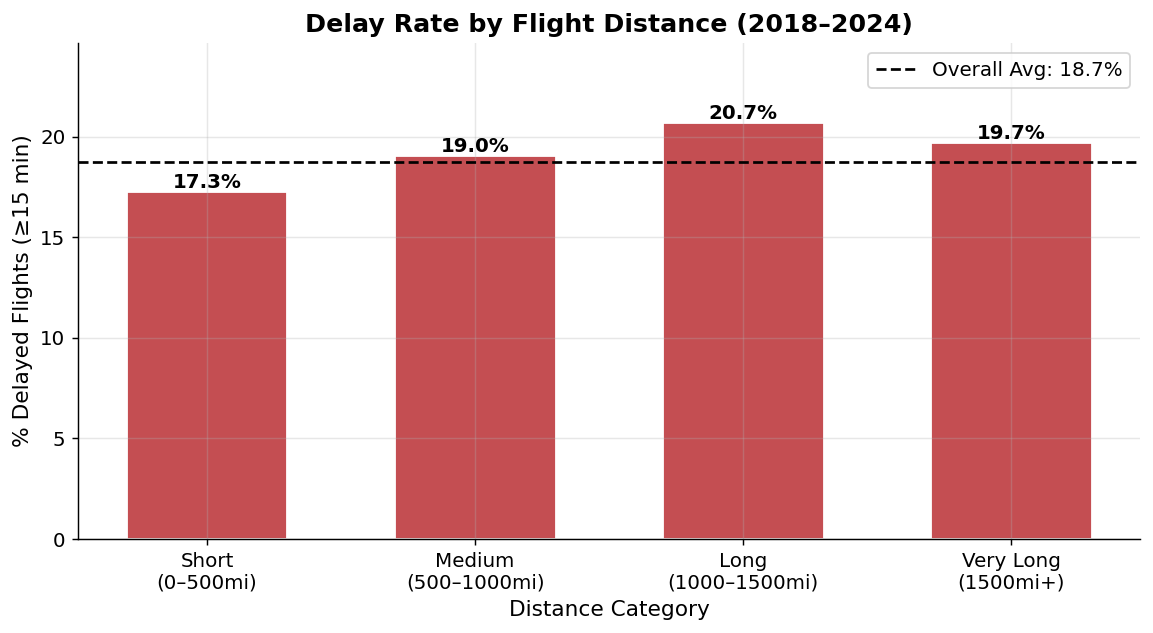

In [64]:
# Bin distance into 4 groups
bins = [0, 500, 1000, 1500, df['Distance'].max()]
labels = ['Short\n(0–500mi)', 'Medium\n(500–1000mi)', 'Long\n(1000–1500mi)', 'Very Long\n(1500mi+)']

df['DistanceBin'] = pd.cut(df['Distance'], bins=bins, labels=labels)

dist_delay = (
    df.dropna(subset=['ArrDel15', 'DistanceBin'])
    .groupby('DistanceBin', observed=True)['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

dist_delay['Pct_Delayed'] = dist_delay['Pct_Delayed'].astype(float)

print(dist_delay)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    dist_delay['DistanceBin'].astype(str),
    dist_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Flight Distance (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance Category', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylim(0, dist_delay['Pct_Delayed'].max() + 4)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_distance.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 3 — Key Findings: Distance & Delay

- Short flights (0–500mi) have the lowest delay rate at 17.3%, while long flights (1000–1500mi) peak at 20.7%.
- Very long flights (1500mi+) go to 19.7%, which suggest that flights have more time to make up delays in the air.

## Section 4: Feature Cardinality & Encoding Implications

### 4.1 Feature Cardinality Table

In [65]:
features = ['Reporting_Airline', 'Origin', 'Dest', 'DepTimeBlk',
            'Month', 'DayOfWeek', 'DayofMonth', 'DistanceGroup',
            'dep_hour', 'is_weekend', 'is_holiday']

cardinality = []
for col in features:
    n = df[col].nunique()
    if n <= 20:
        level = 'Low'
    elif n <= 100:
        level = 'Medium'
    else:
        level = 'High'
    cardinality.append({'Feature': col, 'Unique Values': n, 'Cardinality': level})

card_df = pd.DataFrame(cardinality).sort_values('Unique Values', ascending=False)
print(card_df.to_string(index=False))

          Feature  Unique Values Cardinality
           Origin            384        High
             Dest            384        High
       DayofMonth             31      Medium
         dep_hour             25      Medium
Reporting_Airline             19         Low
       DepTimeBlk             19         Low
            Month             12         Low
    DistanceGroup             11         Low
        DayOfWeek              7         Low
       is_weekend              2         Low
       is_holiday              2         Low


### 4.2 Cardinality Bar Chart

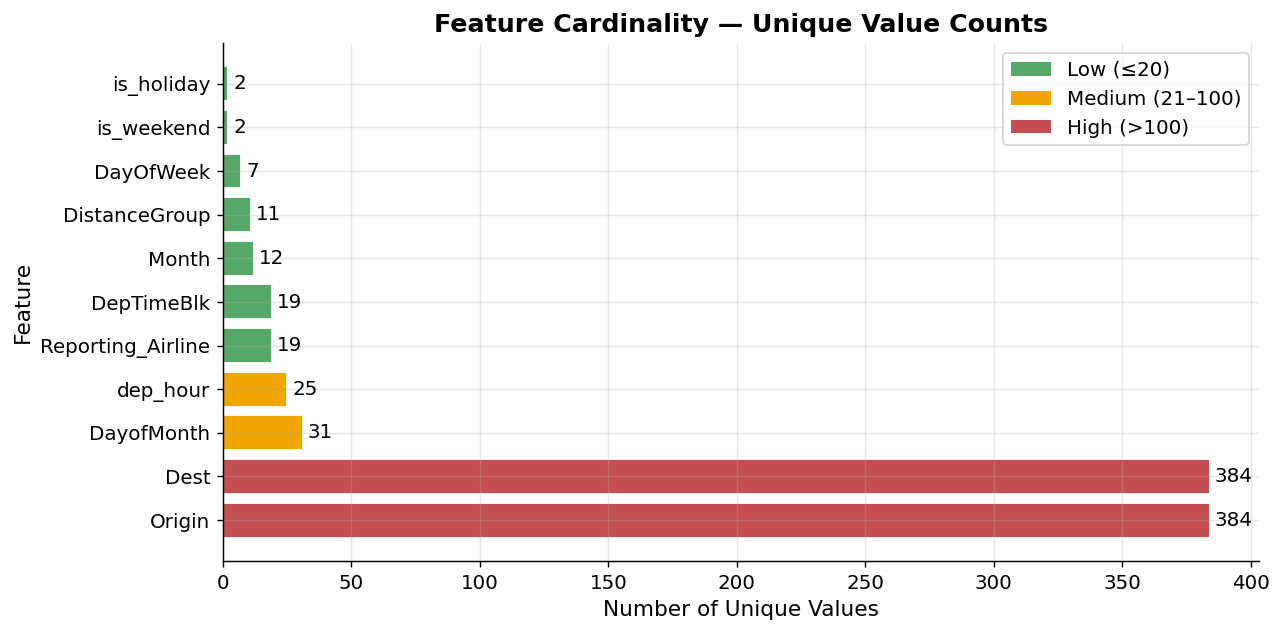

In [66]:
color_map = {'Low': '#55a868', 'Medium': '#f0a500', 'High': '#c44e52'}
colors = [color_map[c] for c in card_df['Cardinality']]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    card_df['Feature'],
    card_df['Unique Values'],
    color=colors,
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va='center',
        fontsize=11
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#55a868', label='Low (≤20)'),
    Patch(facecolor='#f0a500', label='Medium (21–100)'),
    Patch(facecolor='#c44e52', label='High (>100)')
]
ax.legend(handles=legend_elements, fontsize=11)

ax.set_title('Feature Cardinality — Unique Value Counts', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Unique Values', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Encoding Implications

- `Origin` and `Dest` (384 unique values each) are high cardinality — one-hot encoding would create 768 sparse columns, making the model slower and harder to train. Target encoding (replacing each airport with its historical delay rate) is the best option.
- `Reporting_Airline` and `DepTimeBlk` (19 unique values each) are low cardinality and safe to one-hot encode.
- Numeric and ordinal features (`Month`, `DayOfWeek`, `DayofMonth`, `DistanceGroup`, `dep_hour`) can be used as-is — no encoding needed.
- Weather features (`origin_*`, `dest_*`) are all continuous (float) or binary (0/1) and can be used as-is. **Exception:** `origin_gust_kts` and `dest_gust_kts` have ~75% missingness and should be excluded from modeling.
- `is_weekend` and `is_holiday` are binary features, ready to use as-is.

## Section 5: Conclusion

This EDA examines feature relationships across categorical, temporal, and distance dimensions to understand what drives flight arrival delays and what that means for model selection.

**Key findings:**

- Airline and airport are the strongest predictors — delay rates range from 14.1% to 26.9% across carriers and 13.9% to 24.9% across airports.
- Time of day shows a strong nonlinear pattern — delay rates are lowest at 5am (8.6%) and peak in the evening (26%).
- Distance has a weaker effect but interacts with airline and airport — long-haul routes tend to connect busy hubs with already-high delay rates.

**Modeling implications:**

- Strong nonlinear interactions between time-of-day, carrier, and airport suggest tree-based models (Random Forest, XGBoost) are well-suited for this task. These patterns cannot be adequately captured by logistic regression as it assumes linear relationships between features and the target.
- `is_weekend`, `is_holiday`, and weather features (`origin_*`, `dest_*`) are included in the dataset and ready to use — `origin_gust_kts` and `dest_gust_kts` should be excluded due to ~75% missingness.